In [45]:
# Install all libraries
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap joblib \
alibi captum pdpbox eli5 imbalanced-learn sdv


Load dataset

In [46]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Path to your dataset
dataset_path = '/content/drive/MyDrive/Crop_recommendation.csv'

# Load dataset
df = pd.read_csv(dataset_path)

# Preview dataset
print("Shape of dataset:", df.shape)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape of dataset: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


Data per crop inspection

In [47]:
# Basic dataset information
print("\nDataset Info:")
print(df.info())

# Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Basic descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())

# Unique crops in the dataset
print("\nUnique Crops:")
print(df['label'].unique())

# Number of unique crops
print("\nNumber of unique crops:", df['label'].nunique())

# Count of samples per crop
print("\nSamples per Crop:")
print(df['label'].value_counts())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None

Missing Values per Column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Descriptive Statistics:
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.14

Synthetic data generation

Original dataset shape: (2200, 8)
Number of crops: 22

Training CTGAN for crop: rice

Training CTGAN for crop: maize

Training CTGAN for crop: chickpea

Training CTGAN for crop: kidneybeans

Training CTGAN for crop: pigeonpeas

Training CTGAN for crop: mothbeans

Training CTGAN for crop: mungbean

Training CTGAN for crop: blackgram

Training CTGAN for crop: lentil

Training CTGAN for crop: pomegranate

Training CTGAN for crop: banana

Training CTGAN for crop: mango

Training CTGAN for crop: grapes

Training CTGAN for crop: watermelon

Training CTGAN for crop: muskmelon

Training CTGAN for crop: apple

Training CTGAN for crop: orange

Training CTGAN for crop: papaya

Training CTGAN for crop: coconut

Training CTGAN for crop: cotton

Training CTGAN for crop: jute

Training CTGAN for crop: coffee
Synthetic dataset shape: (4400, 8)
Expanded dataset shape: (6600, 8)

Sample counts per crop:
 label
rice           300
maize          300
jute           300
cotton         300
coconut        300

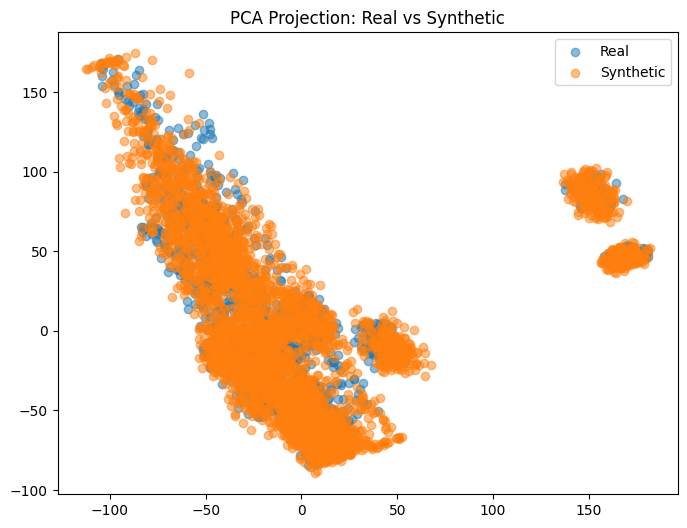


Expanded dataset saved successfully.


In [48]:
# Install package
!pip install ctgan

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from ctgan import CTGAN

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Crop_recommendation.csv')
df['label'] = df['label'].astype('category')

print("Original dataset shape:", df.shape)
print("Number of crops:", df['label'].nunique())

synthetic_data_list = []

# Train separate CTGAN for each crop
for crop in df['label'].unique():
    crop_df = df[df['label'] == crop].copy().reset_index(drop=True)

    # Drop label column for training — only numeric features remain
    features_only = crop_df.drop(columns=['label'])

    print(f"\nTraining CTGAN for crop: {crop}")
    ctgan = CTGAN(epochs=500, batch_size=20)
    ctgan.fit(features_only)

    # Generate synthetic rows
    synth_crop = ctgan.sample(200)

    # Add the crop label back
    synth_crop['label'] = crop

    synthetic_data_list.append(synth_crop)

# Combine synthetic data
synthetic_df = pd.concat(synthetic_data_list, ignore_index=True)
print("Synthetic dataset shape:", synthetic_df.shape)

# Clip synthetic values to real min/max per feature
for col in df.columns:
    if col != 'label':
        min_val, max_val = df[col].min(), df[col].max()
        synthetic_df[col] = synthetic_df[col].clip(lower=min_val, upper=max_val)

# Combine real + synthetic
expanded_df = pd.concat([df, synthetic_df], ignore_index=True)
print("Expanded dataset shape:", expanded_df.shape)
print("\nSample counts per crop:\n", expanded_df['label'].value_counts())

# Validation: Range check
print("\n[Range Check] Values outside original data range after clipping:")
for col in df.columns:
    if col != 'label':
        min_real, max_real = df[col].min(), df[col].max()
        out_of_range = synthetic_df[(synthetic_df[col] < min_real) | (synthetic_df[col] > max_real)]
        print(f"{col}: {len(out_of_range)} out-of-range values")

# Statistical comparison
print("\n[Statistical Comparison: Real vs Synthetic]")
for col in df.columns:
    if col != 'label':
        print(f"\nFeature: {col}")
        print(f"Real   - Mean: {df[col].mean():.3f}, Std: {df[col].std():.3f}")
        print(f"Synth  - Mean: {synthetic_df[col].mean():.3f}, Std: {synthetic_df[col].std():.3f}")

# PCA overlap visualization
num_features = [c for c in df.columns if c != 'label']
pca = PCA(n_components=2)
real_pca = pca.fit_transform(df.drop(columns=['label']))
synthetic_pca = pca.transform(synthetic_df.drop(columns=['label']))

plt.figure(figsize=(8, 6))
plt.scatter(real_pca[:, 0], real_pca[:, 1], alpha=0.5, label='Real')
plt.scatter(synthetic_pca[:, 0], synthetic_pca[:, 1], alpha=0.5, label='Synthetic')
plt.title("PCA Projection: Real vs Synthetic")
plt.legend()
plt.show()

# Save expanded dataset
expanded_df.to_csv('/content/drive/MyDrive/Crop_recommendation_expanded.csv', index=False)
print("\nExpanded dataset saved successfully.")


Crop specific binary classification model

In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load expanded dataset
df = pd.read_csv('/content/drive/MyDrive/Crop_recommendation_expanded.csv')

# Create binary target: 1 for rice, 0 for others
df['target'] = (df['label'] == 'rice').astype(int)

# Separate positive and negative classes
df_rice = df[df['target'] == 1]
df_not_rice = df[df['target'] == 0]

print(f"Rice samples: {len(df_rice)}")
print(f"Not-rice samples: {len(df_not_rice)}")

# Downsample not-rice to match rice count
df_not_rice_down = df_not_rice.sample(n=len(df_rice), random_state=42)

# Combine balanced dataset
df_balanced = pd.concat([df_rice, df_not_rice_down], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nBalanced dataset shape: {df_balanced.shape}")
print(df_balanced['target'].value_counts())

# Separate features (X) and target (y)
X = df_balanced.drop(columns=['label', 'target'])
y = df_balanced['target']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Class distribution in Train:", y_train.value_counts(normalize=True))
print("Class distribution in Test:", y_test.value_counts(normalize=True))


Rice samples: 300
Not-rice samples: 6300

Balanced dataset shape: (600, 9)
target
1    300
0    300
Name: count, dtype: int64

Train shape: (480, 7), Test shape: (120, 7)
Class distribution in Train: target
0    0.5
1    0.5
Name: proportion, dtype: float64
Class distribution in Test: target
0    0.5
1    0.5
Name: proportion, dtype: float64


Training and evaluation of XGB and RF on Rice

In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Load expanded dataset
df = pd.read_csv('/content/drive/MyDrive/Crop_recommendation_expanded.csv')
df['target'] = (df['label'] == 'rice').astype(int)

# Helper: Train & evaluate any model
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # For SVM without probability, we use decision_function
        y_proba = model.decision_function(X_test)
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

# Prepare results storage
results = {"Balanced": {}, "Imbalanced": {}}

#balanced dataset
df_rice = df[df['target'] == 1]
df_not_rice = df[df['target'] == 0].sample(n=len(df_rice), random_state=42)
df_bal = pd.concat([df_rice, df_not_rice]).sample(frac=1, random_state=42).reset_index(drop=True)

X_bal = df_bal.drop(columns=['label', 'target'])
y_bal = df_bal['target']
Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=42)

# Models for balanced case
models_bal = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5,
                              subsample=0.8, colsample_bytree=0.8, random_state=42,
                              eval_metric='logloss'),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
}

# Train & evaluate each model
for name, model in models_bal.items():
    results["Balanced"][name] = evaluate_model(model, Xb_train, Xb_test, yb_train, yb_test)


X_imb = df.drop(columns=['label', 'target'])
y_imb = df['target']
Xi_train, Xi_test, yi_train, yi_test = train_test_split(X_imb, y_imb, test_size=0.2, stratify=y_imb, random_state=42)

#Unbalanced dataset
# Class weights / pos_weight for imbalance handling
neg_pos_ratio = (yi_train == 0).sum() / (yi_train == 1).sum()

models_imb = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5,
                              subsample=0.8, colsample_bytree=0.8, random_state=42,
                              eval_metric='logloss', scale_pos_weight=neg_pos_ratio),
    "DecisionTree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "SVM": SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
}

# Train & evaluate each model
for name, model in models_imb.items():
    results["Imbalanced"][name] = evaluate_model(model, Xi_train, Xi_test, yi_train, yi_test)

rows = []
for case, metrics_dict in results.items():
    for model_name, metric_values in metrics_dict.items():
        row = {
            "Case": case,
            "Model": model_name,
            **metric_values
        }
        rows.append(row)

results_df = pd.DataFrame(rows)
print(results_df)

# Optional: Pretty print sorted by Case, then ROC-AUC
results_df = results_df.sort_values(by=["Case", "ROC-AUC"], ascending=[True, False])
print("\nSorted Results:")
print(results_df.to_string(index=False))

#Accuracy - what % of predictions were correct
#Precision - of all times it said rice how many were correct
#Recall - of all actual rice samples how many the model correctly finds
#F1 - 2 * (precision * recall)/(precision + recall)
#ROC -AUC = how well is the separation region between rice and not rice threshold regions


         Case         Model  Accuracy  Precision    Recall        F1   ROC-AUC
0    Balanced  RandomForest  0.983333   0.983333  0.983333  0.983333  0.999722
1    Balanced       XGBoost  0.983333   0.983333  0.983333  0.983333  0.998611
2    Balanced  DecisionTree  0.991667   1.000000  0.983333  0.991597  0.991667
3    Balanced           SVM  0.983333   0.967742  1.000000  0.983607  0.991667
4    Balanced           MLP  0.991667   0.983607  1.000000  0.991736  0.996389
5  Imbalanced  RandomForest  0.993939   0.964286  0.900000  0.931034  0.999345
6  Imbalanced       XGBoost  0.993939   0.906250  0.966667  0.935484  0.999643
7  Imbalanced  DecisionTree  0.993939   0.919355  0.950000  0.934426  0.973016
8  Imbalanced           SVM  0.956818   0.512821  1.000000  0.677966  0.996204
9  Imbalanced           MLP  0.993182   0.947368  0.900000  0.923077  0.997897

Sorted Results:
      Case        Model  Accuracy  Precision   Recall       F1  ROC-AUC
  Balanced RandomForest  0.983333   0.9833

Shap implementation for all 5 models


=== Running SHAP for Balanced dataset ===

[balanced] Training RandomForest...


/tmp/ipython-input-3924547226.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, show=True)
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


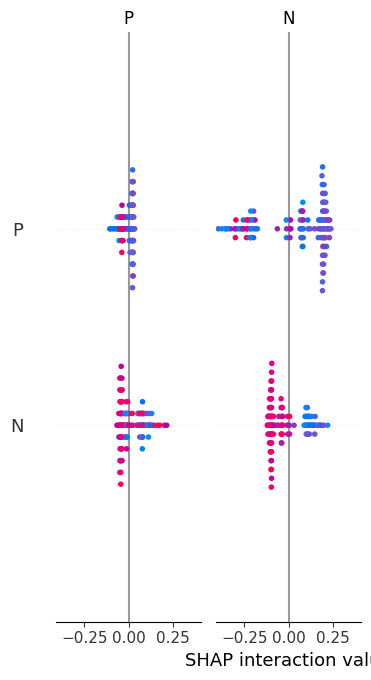

/tmp/ipython-input-3924547226.py:82: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, plot_type="bar", show=True)
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


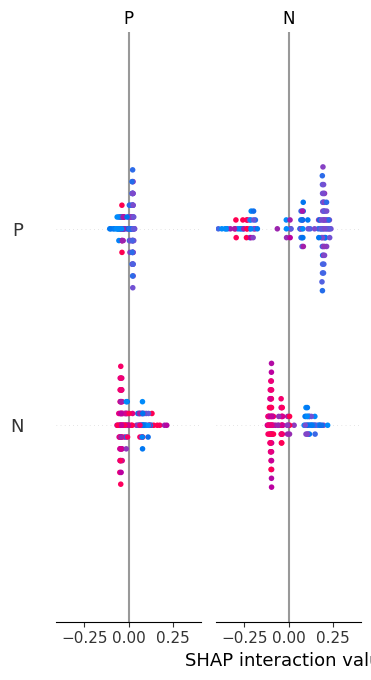


[balanced] Training XGBoost...


/tmp/ipython-input-3924547226.py:88: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, show=True)


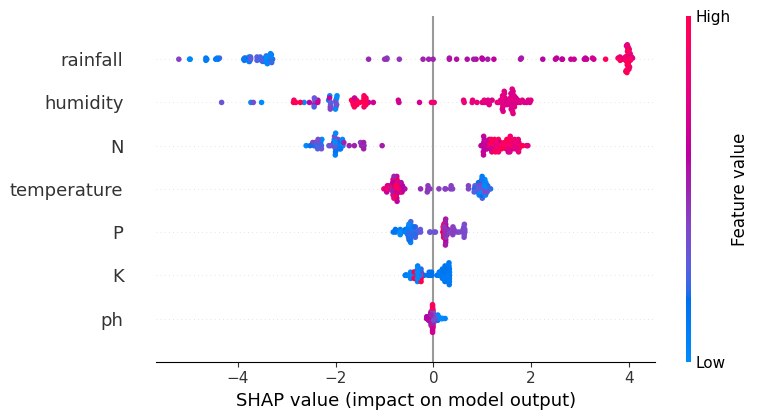

/tmp/ipython-input-3924547226.py:89: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, plot_type="bar", show=True)


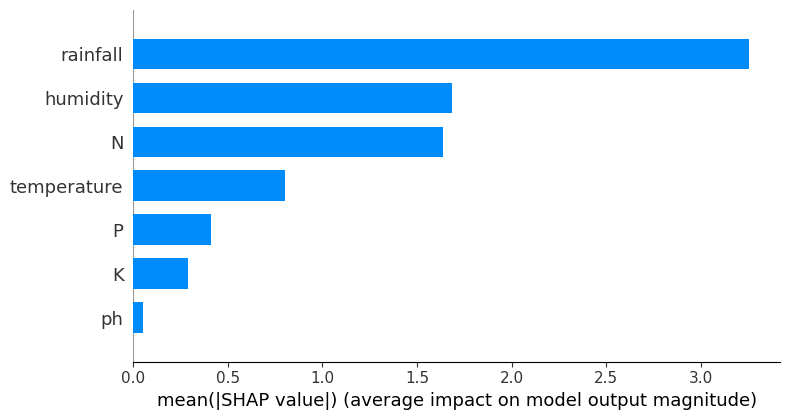

/tmp/ipython-input-3924547226.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, show=True)
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(



[balanced] Training DecisionTree...


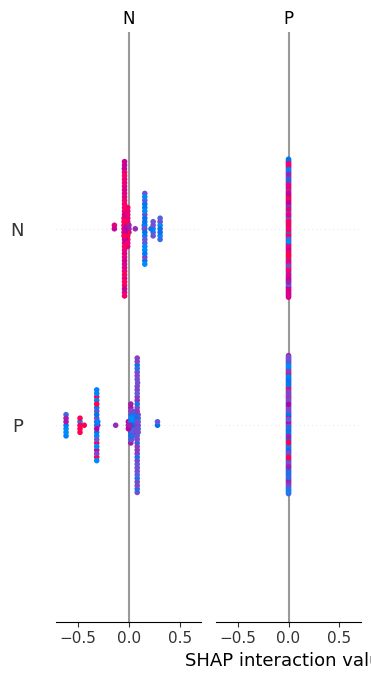

/tmp/ipython-input-3924547226.py:82: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, plot_type="bar", show=True)
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


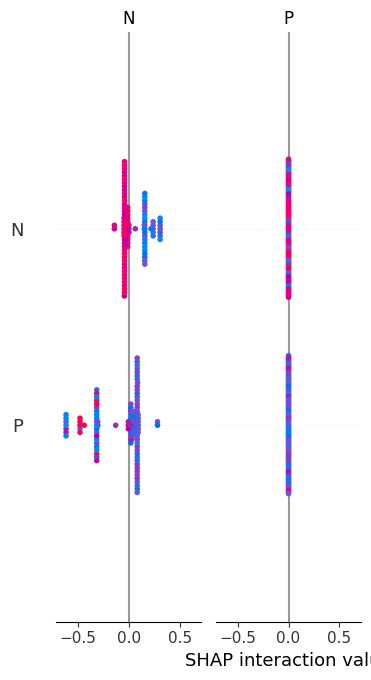


[balanced] Training SVM...


  0%|          | 0/120 [00:00<?, ?it/s]

/tmp/ipython-input-3924547226.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_combined, X_test, feature_names=feature_names, show=True)


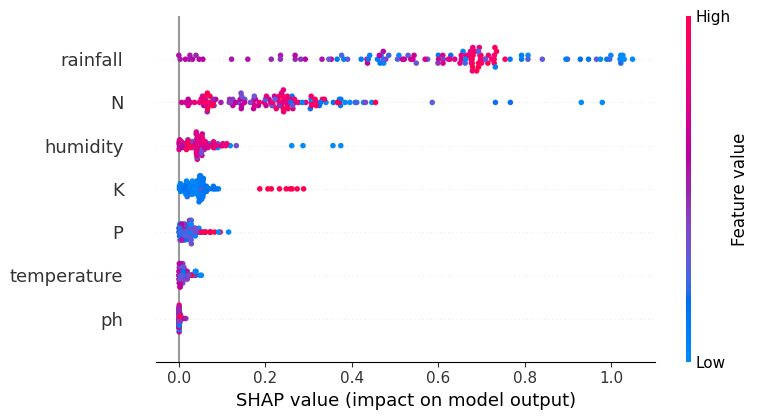

/tmp/ipython-input-3924547226.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_combined, X_test, feature_names=feature_names, plot_type="bar", show=True)


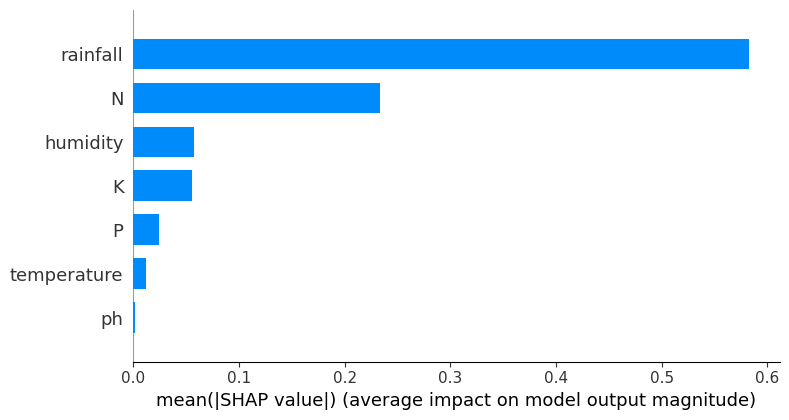


[balanced] Training MLP...


  0%|          | 0/120 [00:00<?, ?it/s]

/tmp/ipython-input-3924547226.py:47: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_combined, X_test, feature_names=feature_names, show=True)


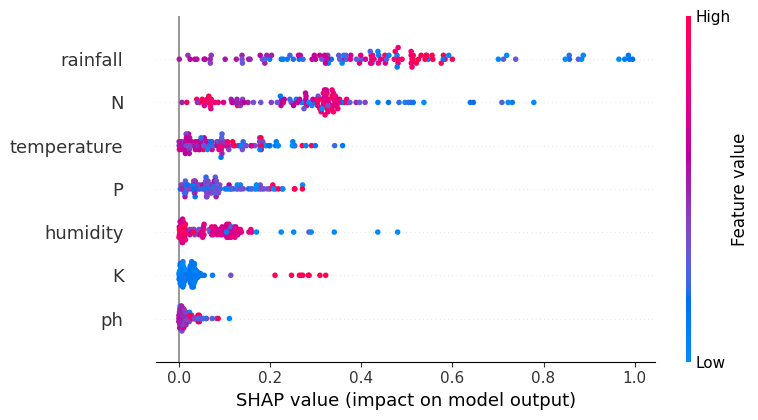

/tmp/ipython-input-3924547226.py:48: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_combined, X_test, feature_names=feature_names, plot_type="bar", show=True)


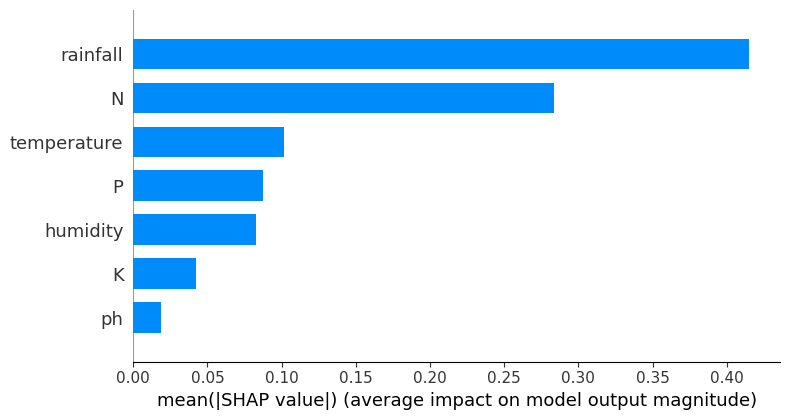

[balanced] Feature importance saved.

=== Running SHAP for Imbalanced dataset ===

[imbalanced] Training RandomForest...


/tmp/ipython-input-3924547226.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, show=True)
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


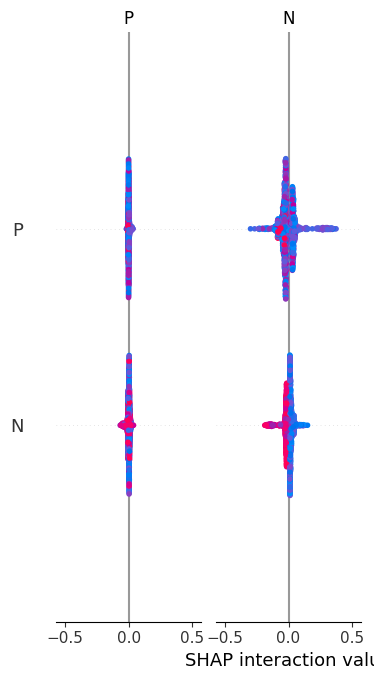

/tmp/ipython-input-3924547226.py:82: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, plot_type="bar", show=True)
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


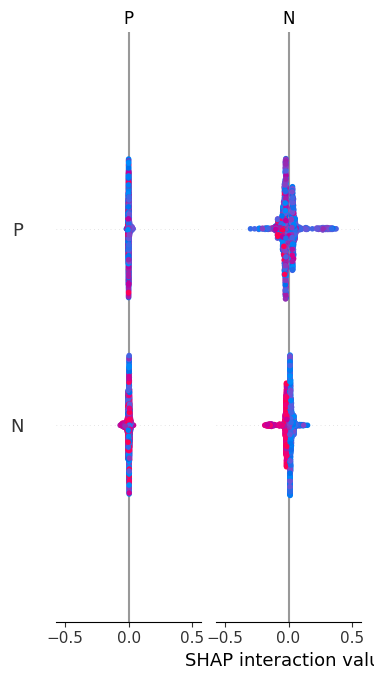


[imbalanced] Training XGBoost...


/tmp/ipython-input-3924547226.py:88: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, show=True)


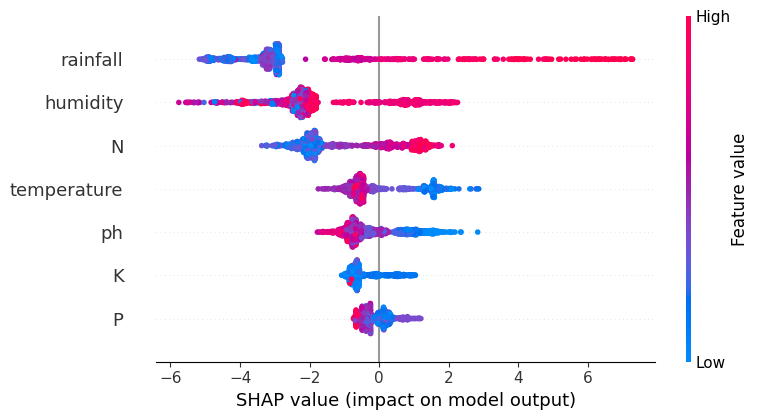

/tmp/ipython-input-3924547226.py:89: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, plot_type="bar", show=True)


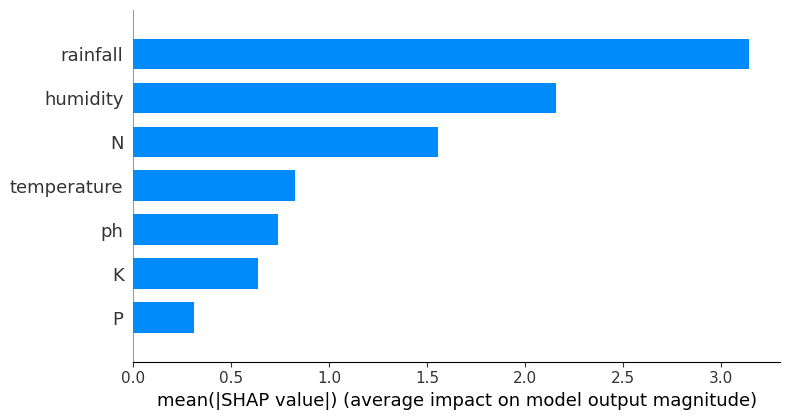

/tmp/ipython-input-3924547226.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, show=True)
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(



[imbalanced] Training DecisionTree...


/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


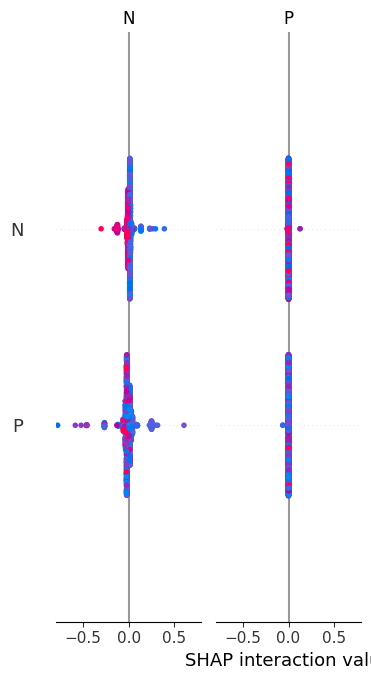

/tmp/ipython-input-3924547226.py:82: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, plot_type="bar", show=True)
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


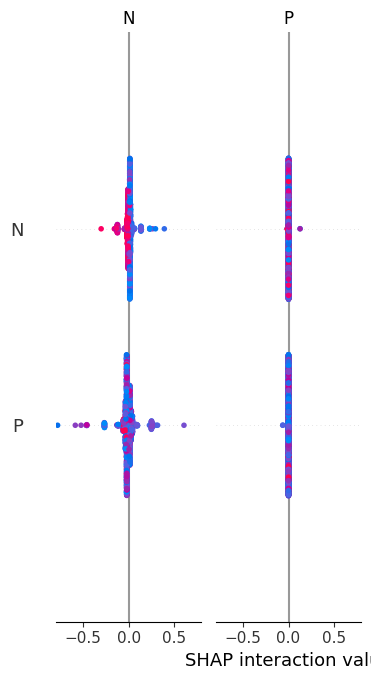


[imbalanced] Training SVM...


  0%|          | 0/1320 [00:00<?, ?it/s]

/tmp/ipython-input-3924547226.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_combined, X_test, feature_names=feature_names, show=True)


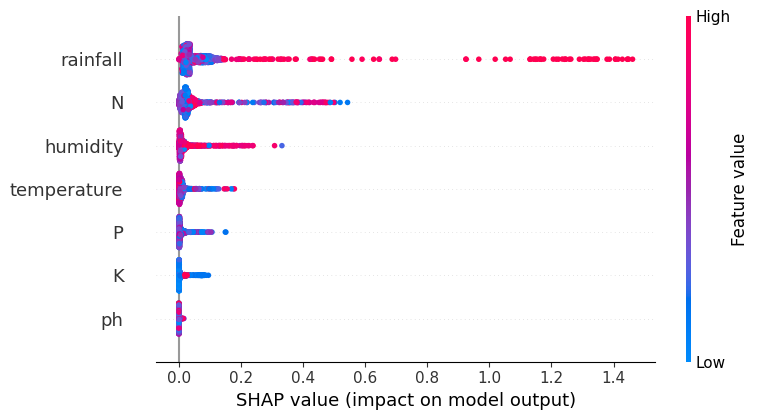

/tmp/ipython-input-3924547226.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_combined, X_test, feature_names=feature_names, plot_type="bar", show=True)


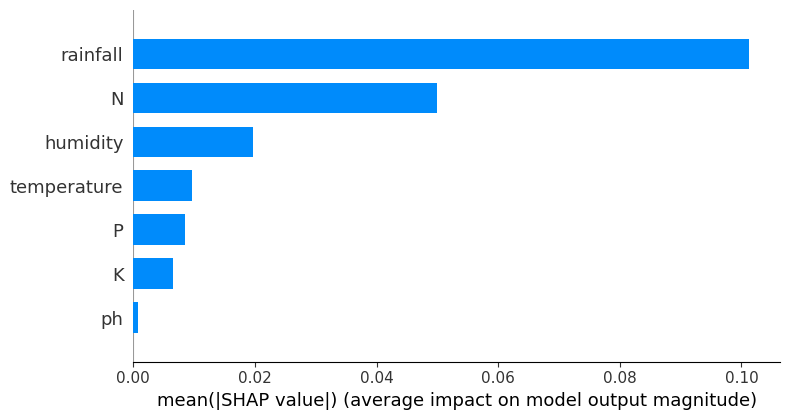


[imbalanced] Training MLP...


  0%|          | 0/1320 [00:00<?, ?it/s]

/tmp/ipython-input-3924547226.py:47: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_combined, X_test, feature_names=feature_names, show=True)


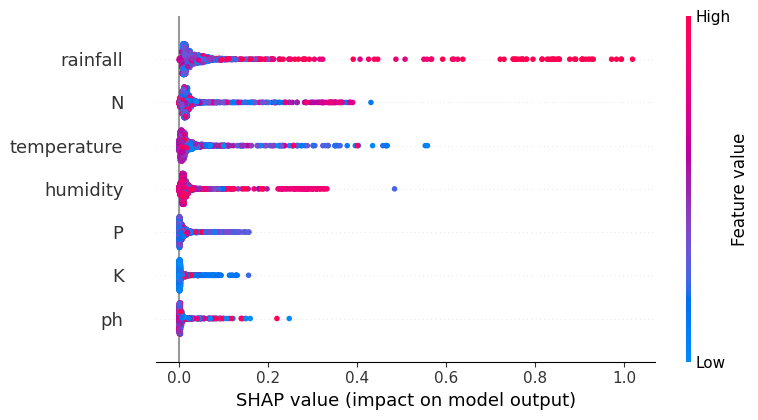

/tmp/ipython-input-3924547226.py:48: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_combined, X_test, feature_names=feature_names, plot_type="bar", show=True)


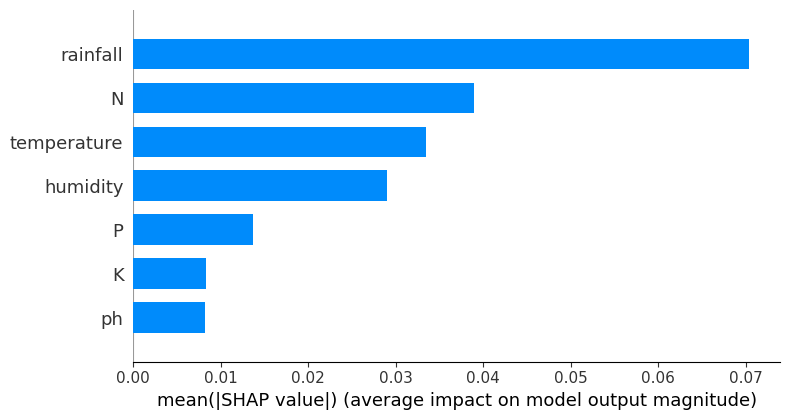

[imbalanced] Feature importance saved.


In [51]:
import shap
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

# ----------------------
# Helper: SVM SHAP
# ----------------------
def explain_svm_with_shap(model, X_train, X_test, feature_names):
    X_train_np = np.array(X_train)
    X_test_np = np.array(X_test)

    explainer = shap.KernelExplainer(
        model.predict_proba,
        shap.sample(X_train_np, 50, random_state=42)
    )
    raw_shap = np.array(explainer.shap_values(X_test_np, nsamples=100))
    if raw_shap.shape[0] != 2:  # If class axis not first
        raw_shap = np.transpose(raw_shap, (2, 0, 1))
    shap_values_combined = np.sum(np.abs(raw_shap), axis=0)
    assert shap_values_combined.shape == (len(X_test), len(feature_names))
    shap.summary_plot(shap_values_combined, X_test, feature_names=feature_names, show=True)
    shap.summary_plot(shap_values_combined, X_test, feature_names=feature_names, plot_type="bar", show=True)
    return shap_values_combined

# ----------------------
# Helper: MLP SHAP
# ----------------------
def explain_mlp_with_shap(model, X_train, X_test, feature_names):
    X_train_np = np.array(X_train)
    X_test_np = np.array(X_test)

    explainer = shap.KernelExplainer(
        model.predict_proba,
        shap.sample(X_train_np, 50, random_state=42)
    )
    raw_shap = np.array(explainer.shap_values(X_test_np, nsamples=100))
    if raw_shap.shape[0] != 2:
        raw_shap = np.transpose(raw_shap, (2, 0, 1))
    shap_values_combined = np.sum(np.abs(raw_shap), axis=0)
    assert shap_values_combined.shape == (len(X_test), len(feature_names))
    shap.summary_plot(shap_values_combined, X_test, feature_names=feature_names, show=True)
    shap.summary_plot(shap_values_combined, X_test, feature_names=feature_names, plot_type="bar", show=True)
    return shap_values_combined

# ----------------------
# Main SHAP runner
# ----------------------
def run_shap_for_case(X_train, X_test, y_train, dataset_case):
    models = {
        "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
        "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5,
                                 subsample=0.8, colsample_bytree=0.8, random_state=42,
                                 eval_metric='logloss'),
        "DecisionTree": DecisionTreeClassifier(random_state=42),
        "SVM": SVC(kernel='rbf', probability=True, random_state=42),
        "MLP": MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
    }

    fi_all = {}

    for name, model in models.items():
        print(f"\n[{dataset_case}] Training {name}...")
        model.fit(X_train, y_train)

        if name in ["RandomForest", "DecisionTree"]:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test)

            # Combine SHAP values from both classes
            if isinstance(shap_values, list) and len(shap_values) == 2:
                shap_values = np.sum(np.abs(shap_values), axis=0)  # (samples, features)

            mean_abs_shap = np.abs(shap_values).mean(axis=0)

            shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, show=True)
            shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, plot_type="bar", show=True)

        elif name == "XGBoost":
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test)
            mean_abs_shap = np.abs(shap_values).mean(axis=0)
            shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, show=True)
            shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, plot_type="bar", show=True)

        elif name == "SVM":
            mean_abs_shap = explain_svm_with_shap(model, X_train, X_test, X_train.columns)

        elif name == "MLP":
            mean_abs_shap = explain_mlp_with_shap(model, X_train, X_test, X_train.columns)

        fi_all[name] = dict(zip(X_train.columns, mean_abs_shap))

    # Save feature importance
    pd.DataFrame(fi_all).T.to_csv(f"/content/drive/MyDrive/rice_shap_feature_importance_{dataset_case}.csv")
    print(f"[{dataset_case}] Feature importance saved.")

# ----------------------
# Load dataset
# ----------------------
df = pd.read_csv('/content/drive/MyDrive/Crop_recommendation_expanded.csv')
df['target'] = (df['label'] == 'rice').astype(int)

# ----------------------
# Balanced dataset
# ----------------------
df_rice = df[df['target'] == 1]
df_not_rice = df[df['target'] == 0].sample(n=len(df_rice), random_state=42)
df_bal = pd.concat([df_rice, df_not_rice]).sample(frac=1, random_state=42).reset_index(drop=True)

X_bal = df_bal.drop(columns=['label', 'target'])
y_bal = df_bal['target']

Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=42)

print("\n=== Running SHAP for Balanced dataset ===")
run_shap_for_case(Xb_train, Xb_test, yb_train, "balanced")

# ----------------------
# Imbalanced dataset
# ----------------------
X_imb = df.drop(columns=['label', 'target'])
y_imb = df['target']

Xi_train, Xi_test, yi_train, yi_test = train_test_split(X_imb, y_imb, test_size=0.2, stratify=y_imb, random_state=42)

print("\n=== Running SHAP for Imbalanced dataset ===")
run_shap_for_case(Xi_train, Xi_test, yi_train, "imbalanced")


Shap for logistic regression

/usr/local/lib/python3.11/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)



[balanced] Training Logistic Regression for SHAP...

=== Logistic Regression (balanced) SHAP Global Feature Importance ===
       Feature  LogReg_balanced_SHAP
6     rainfall              4.967857
0            N              2.392126
3  temperature              1.443833
4     humidity              1.407834
1            P              0.809826
5           ph              0.461479
2            K              0.392520


/tmp/ipython-input-1150021868.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, show=True)


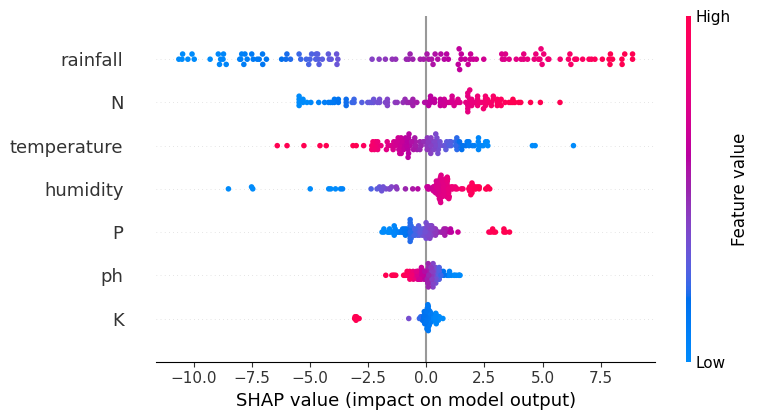

/tmp/ipython-input-1150021868.py:35: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, plot_type="bar", show=True)


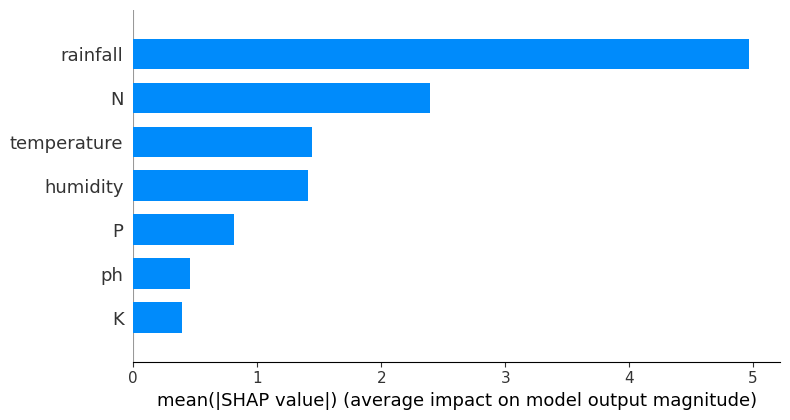


[balanced] Training Logistic Regression for LIME...

=== Logistic Regression (balanced) LIME Global Feature Importance ===
       Feature  LogReg_balanced_LIME
0            N                   0.0
1            P                   0.0
2            K                   0.0
3  temperature                   0.0
4     humidity                   0.0
5           ph                   0.0
6     rainfall                   0.0

[imbalanced] Training Logistic Regression for SHAP...

=== Logistic Regression (imbalanced) SHAP Global Feature Importance ===
       Feature  LogReg_imbalanced_SHAP
6     rainfall                3.289678
0            N                2.829871
4     humidity                2.634340
3  temperature                1.887411
5           ph                0.721943
1            P                0.663952
2            K                0.052114


/usr/local/lib/python3.11/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
/tmp/ipython-input-1150021868.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, show=True)


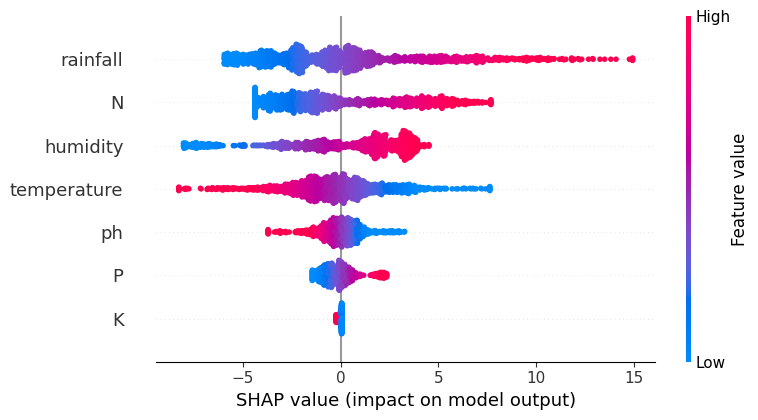

/tmp/ipython-input-1150021868.py:35: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, plot_type="bar", show=True)


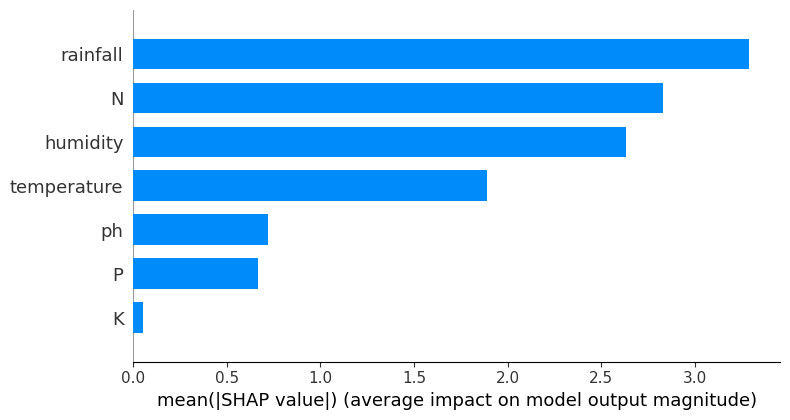


[imbalanced] Training Logistic Regression for LIME...

=== Logistic Regression (imbalanced) LIME Global Feature Importance ===
       Feature  LogReg_imbalanced_LIME
0            N                     0.0
1            P                     0.0
2            K                     0.0
3  temperature                     0.0
4     humidity                     0.0
5           ph                     0.0
6     rainfall                     0.0

=== Final Logistic Regression SHAP + LIME (Balanced & Imbalanced) ===
       Feature  LogReg_balanced_SHAP  LogReg_balanced_LIME  \
0            K              0.392520                   0.0   
1            N              2.392126                   0.0   
2            P              0.809826                   0.0   
3     humidity              1.407834                   0.0   
4           ph              0.461479                   0.0   
5     rainfall              4.967857                   0.0   
6  temperature              1.443833                   

In [52]:
import shap
import numpy as np
import pandas as pd
from lime.lime_tabular import LimeTabularExplainer
from sklearn.linear_model import LogisticRegression

# ----------------------
# Logistic Regression Model
# ----------------------
logreg_model = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42)

# ----------------------
# SHAP Implementation for Logistic Regression
# ----------------------
def run_shap_logreg(model, X_train, X_test, y_train, dataset_case):
    print(f"\n[{dataset_case}] Training Logistic Regression for SHAP...")
    model.fit(X_train, y_train)

    explainer = shap.LinearExplainer(model, X_train, feature_perturbation="interventional")
    shap_values = explainer.shap_values(X_test)

    # Take absolute mean importance
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    shap_df = pd.DataFrame({
        "Feature": X_train.columns,
        f"LogReg_{dataset_case}_SHAP": mean_abs_shap
    }).sort_values(by=f"LogReg_{dataset_case}_SHAP", ascending=False)

    print(f"\n=== Logistic Regression ({dataset_case}) SHAP Global Feature Importance ===")
    print(shap_df)

    # SHAP plots
    shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, show=True)
    shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, plot_type="bar", show=True)

    return shap_df

# ----------------------
# LIME Implementation for Logistic Regression
# ----------------------
def run_lime_logreg(model, X_train, X_test, y_train, dataset_case, target_class=1, num_samples=50):
    print(f"\n[{dataset_case}] Training Logistic Regression for LIME...")
    model.fit(X_train, y_train)

    explainer = LimeTabularExplainer(
        training_data=np.array(X_train),
        feature_names=list(X_train.columns),
        class_names=["not_rice", "rice"],
        mode="classification",
        discretize_continuous=True
    )

    predict_fn = lambda data: model.predict_proba(pd.DataFrame(data, columns=X_train.columns))

    np.random.seed(42)
    sample_indices = np.random.choice(len(X_test), size=min(num_samples, len(X_test)), replace=False)

    all_local_importances = []

    for idx in sample_indices:
        exp = explainer.explain_instance(
            data_row=X_test.iloc[idx].values,
            predict_fn=predict_fn,
            num_features=len(X_train.columns),
            labels=[target_class]
        )
        local_imp = dict(exp.as_list(label=target_class))
        imp_values = [abs(local_imp.get(feat, 0)) for feat in X_train.columns]
        all_local_importances.append(imp_values)

    mean_abs_importance = np.mean(all_local_importances, axis=0)

    lime_df = pd.DataFrame({
        "Feature": X_train.columns,
        f"LogReg_{dataset_case}_LIME": mean_abs_importance
    }).sort_values(by=f"LogReg_{dataset_case}_LIME", ascending=False)

    print(f"\n=== Logistic Regression ({dataset_case}) LIME Global Feature Importance ===")
    print(lime_df)

    return lime_df

# ----------------------
# Run for Balanced Dataset
# ----------------------
logreg_shap_bal = run_shap_logreg(logreg_model, Xb_train, Xb_test, yb_train, "balanced")
logreg_lime_bal = run_lime_logreg(logreg_model, Xb_train, Xb_test, yb_train, "balanced")

# ----------------------
# Run for Imbalanced Dataset
# ----------------------
logreg_shap_imb = run_shap_logreg(logreg_model, Xi_train, Xi_test, yi_train, "imbalanced")
logreg_lime_imb = run_lime_logreg(logreg_model, Xi_train, Xi_test, yi_train, "imbalanced")

# ----------------------
# Merge Results for Comparison
# ----------------------
final_logreg_df = logreg_shap_bal.merge(logreg_lime_bal, on="Feature", how="outer")
final_logreg_df = final_logreg_df.merge(logreg_shap_imb, on="Feature", how="outer")
final_logreg_df = final_logreg_df.merge(logreg_lime_imb, on="Feature", how="outer")

print("\n=== Final Logistic Regression SHAP + LIME (Balanced & Imbalanced) ===")
print(final_logreg_df)

# Optional: Save
final_logreg_df.to_csv("/content/drive/MyDrive/rice_logreg_shap_lime.csv", index=False)


PFI for all 4 models


[balanced] Training XGB for PFI...


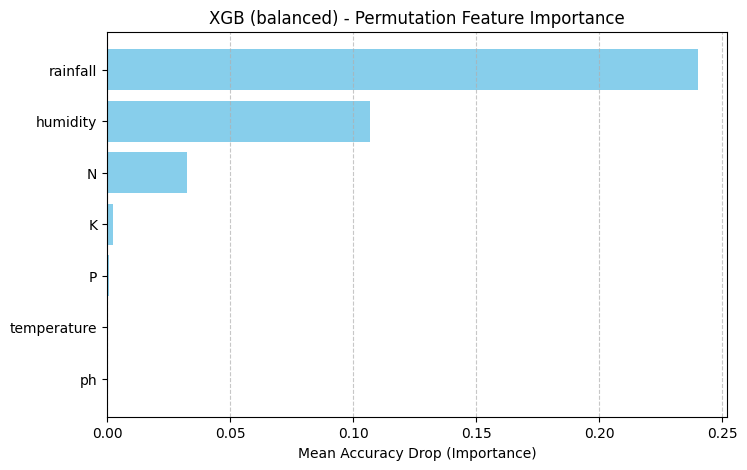


[balanced] Training SVM for PFI...


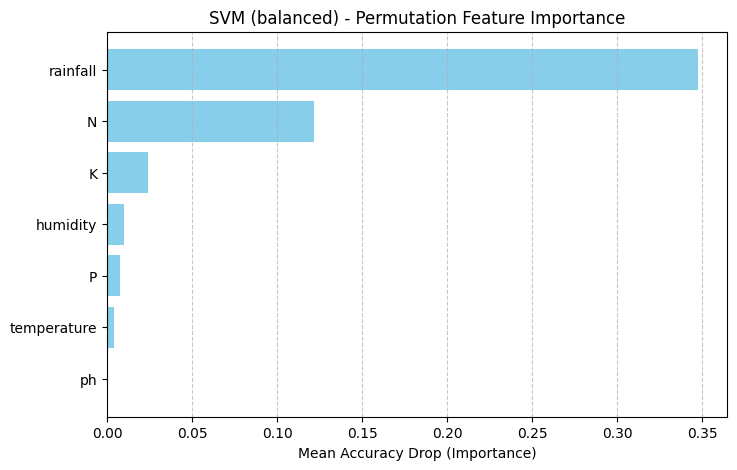


[balanced] Training MLP for PFI...


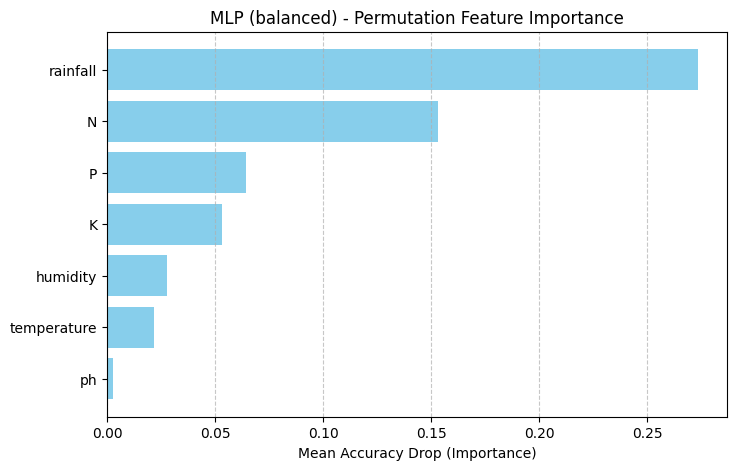


[balanced] Training LogReg for PFI...


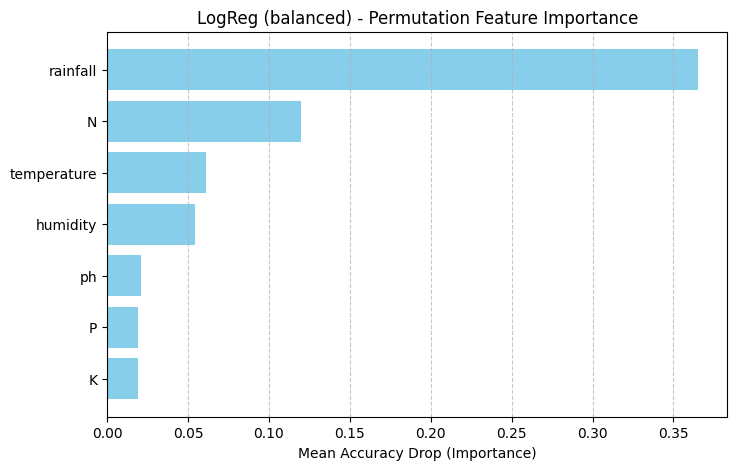


[imbalanced] Training XGB for PFI...


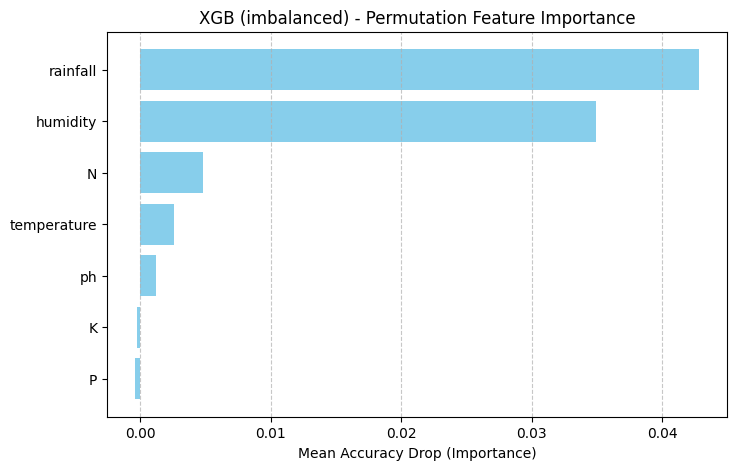


[imbalanced] Training SVM for PFI...


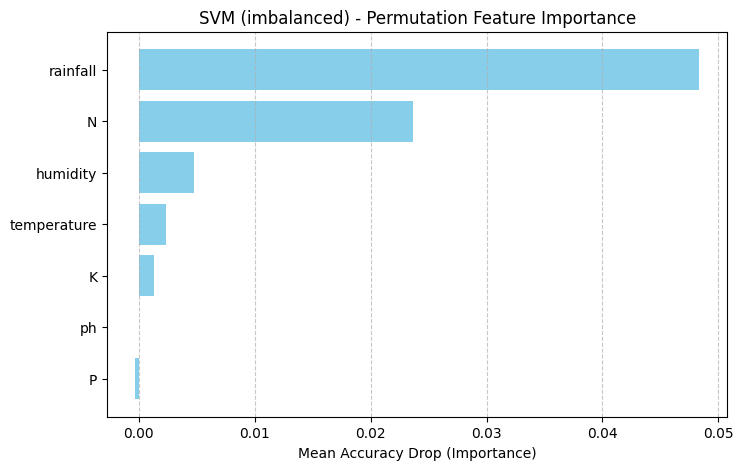


[imbalanced] Training MLP for PFI...


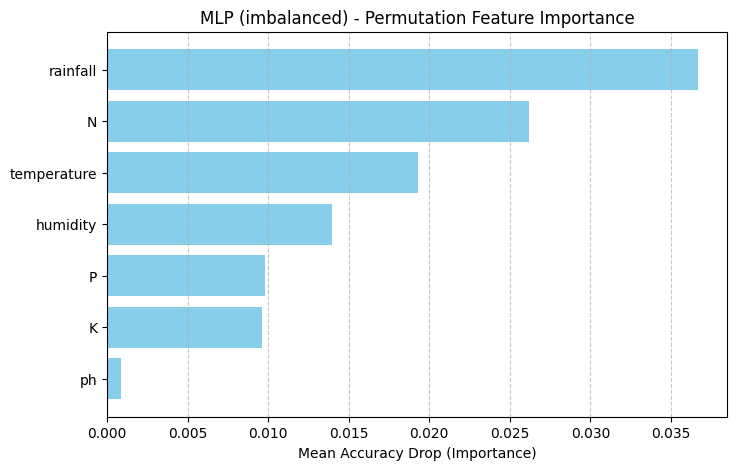


[imbalanced] Training LogReg for PFI...


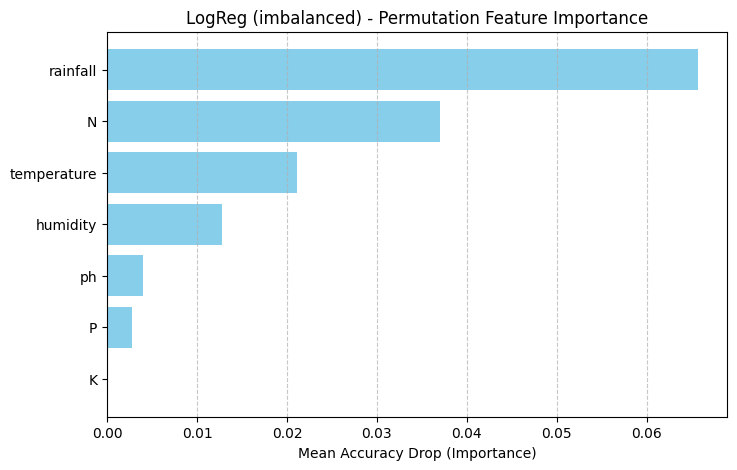


=== Final Combined PFI Feature Importance (Balanced & Imbalanced) ===
       Feature  XGB_balanced_PFI  SVM_balanced_PFI  MLP_balanced_PFI  \
0            K          0.002500          0.024167          0.053333   
1            N          0.032500          0.121667          0.153333   
2            P          0.000833          0.007500          0.064167   
3     humidity          0.106667          0.010000          0.027500   
4           ph          0.000000          0.000000          0.002500   
5     rainfall          0.240000          0.347500          0.273333   
6  temperature          0.000000          0.004167          0.021667   

   LogReg_balanced_PFI  XGB_imbalanced_PFI  SVM_imbalanced_PFI  \
0             0.019167           -0.000227            0.001288   
1             0.120000            0.004773            0.023636   
2             0.019167           -0.000379           -0.000303   
3             0.054167            0.034924            0.004773   
4             0.020833

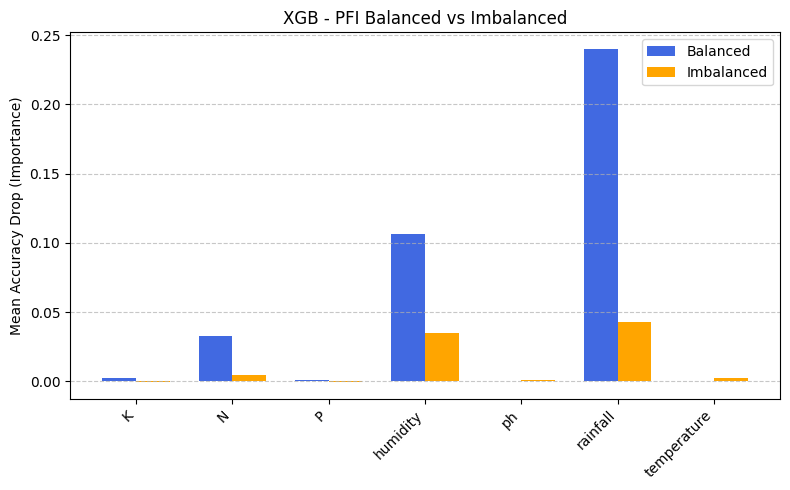

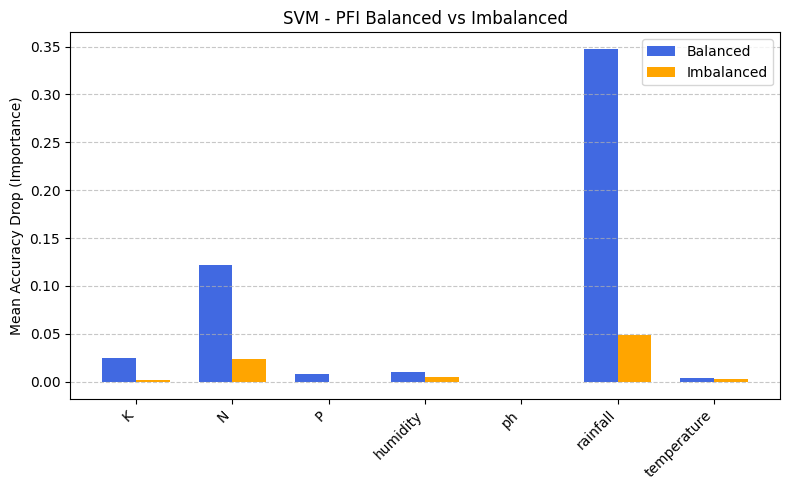

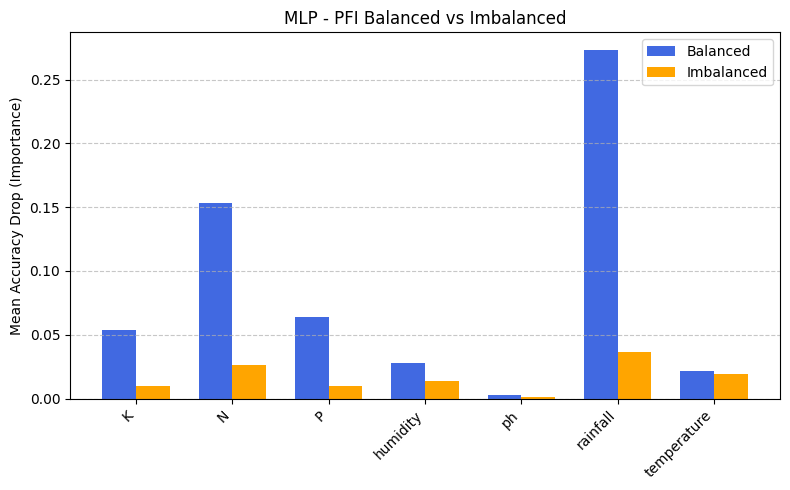

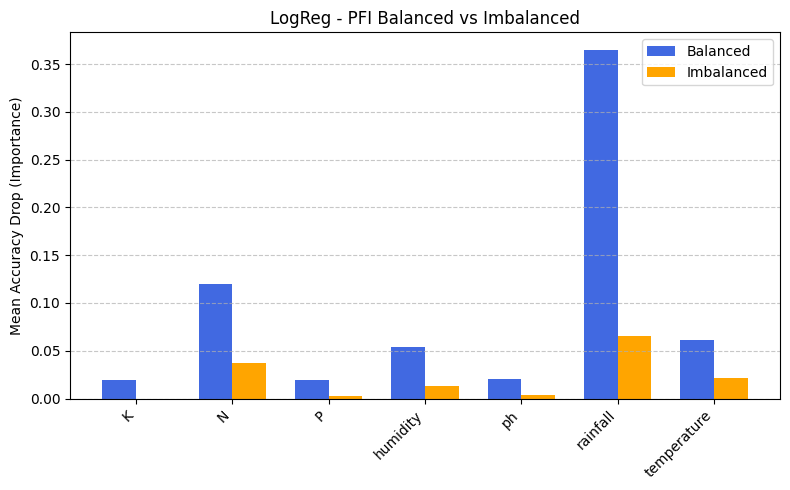

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

# ----------------------
# Helper: Run PFI for a single model
# ----------------------
def run_pfi(model, X_train, X_test, y_train, y_test, model_name, dataset_case):
    print(f"\n[{dataset_case}] Training {model_name} for PFI...")
    model.fit(X_train, y_train)

    # Baseline accuracy
    baseline_acc = accuracy_score(y_test, model.predict(X_test))

    # Run permutation importance
    pfi_result = permutation_importance(
        model, X_test, y_test,
        scoring='accuracy',
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    # Store mean importance
    mean_importance = pfi_result.importances_mean

    # Create DataFrame
    pfi_df = pd.DataFrame({
        "Feature": X_train.columns,
        f"{model_name}_{dataset_case}_PFI": mean_importance
    }).sort_values(by=f"{model_name}_{dataset_case}_PFI", ascending=False).reset_index(drop=True)

    # Plot bar chart for this model & dataset
    plt.figure(figsize=(8, 5))
    plt.barh(pfi_df["Feature"], pfi_df[f"{model_name}_{dataset_case}_PFI"], color="skyblue")
    plt.gca().invert_yaxis()
    plt.title(f"{model_name} ({dataset_case}) - Permutation Feature Importance")
    plt.xlabel("Mean Accuracy Drop (Importance)")
    plt.grid(axis="x", linestyle="--", alpha=0.7)
    plt.show()

    return pfi_df

# ----------------------
# Models
# ----------------------
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

svm_model = SVC(probability=True, kernel="rbf", random_state=42)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

logreg_model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=42
)

# ----------------------
# Run PFI for Balanced Dataset
# ----------------------
results = []
for model, name in [
    (xgb_model, "XGB"),
    (svm_model, "SVM"),
    (mlp_model, "MLP"),
    (logreg_model, "LogReg")
]:
    results.append(run_pfi(model, Xb_train, Xb_test, yb_train, yb_test, name, "balanced"))

# ----------------------
# Run PFI for Imbalanced Dataset
# ----------------------
for model, name in [
    (xgb_model, "XGB"),
    (svm_model, "SVM"),
    (mlp_model, "MLP"),
    (logreg_model, "LogReg")
]:
    results.append(run_pfi(model, Xi_train, Xi_test, yi_train, yi_test, name, "imbalanced"))

# ----------------------
# Merge results into one DataFrame
# ----------------------
final_pfi_df = results[0]
for df in results[1:]:
    final_pfi_df = final_pfi_df.merge(df, on="Feature", how="outer")

print("\n=== Final Combined PFI Feature Importance (Balanced & Imbalanced) ===")
print(final_pfi_df)

# Save to CSV
final_pfi_df.to_csv("/content/drive/MyDrive/rice_pfi_feature_importance.csv", index=False)

# ----------------------
# OPTIONAL: Comparison plot for Balanced vs Imbalanced per model
# ----------------------
for model_name in ["XGB", "SVM", "MLP", "LogReg"]:
    bal_col = f"{model_name}_balanced_PFI"
    imb_col = f"{model_name}_imbalanced_PFI"

    if bal_col in final_pfi_df.columns and imb_col in final_pfi_df.columns:
        plt.figure(figsize=(8, 5))
        width = 0.35
        features = final_pfi_df["Feature"]
        x = np.arange(len(features))

        plt.bar(x - width/2, final_pfi_df[bal_col], width, label="Balanced", color="royalblue")
        plt.bar(x + width/2, final_pfi_df[imb_col], width, label="Imbalanced", color="orange")

        plt.xticks(x, features, rotation=45, ha="right")
        plt.ylabel("Mean Accuracy Drop (Importance)")
        plt.title(f"{model_name} - PFI Balanced vs Imbalanced")
        plt.legend()
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.tight_layout()
        plt.show()


PDP implementation for all 4 models

Top 3 Balanced Features (based on PFI): ['rainfall', 'humidity', 'N']
Top 3 Imbalanced Features (based on PFI): ['rainfall', 'humidity', 'N']

[balanced] Generating PDP for XGB...


<Figure size 600x400 with 0 Axes>

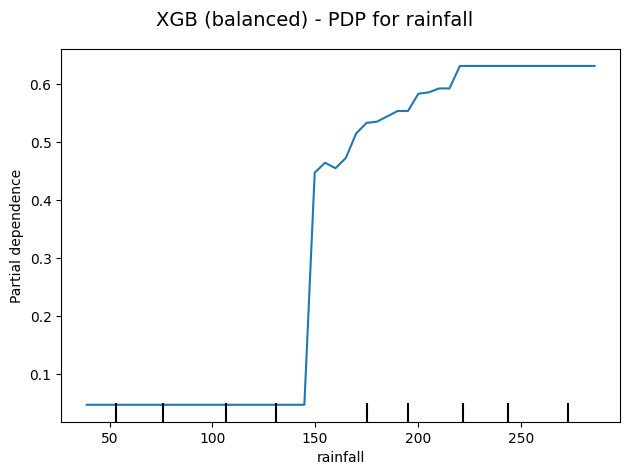

<Figure size 600x400 with 0 Axes>

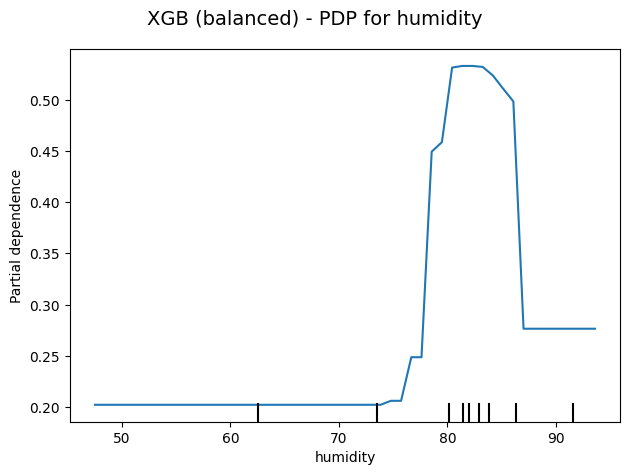

<Figure size 600x400 with 0 Axes>

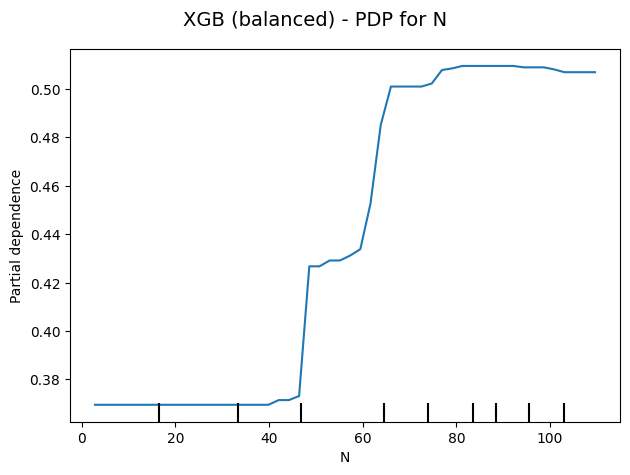


[balanced] Generating PDP for SVM...


<Figure size 600x400 with 0 Axes>

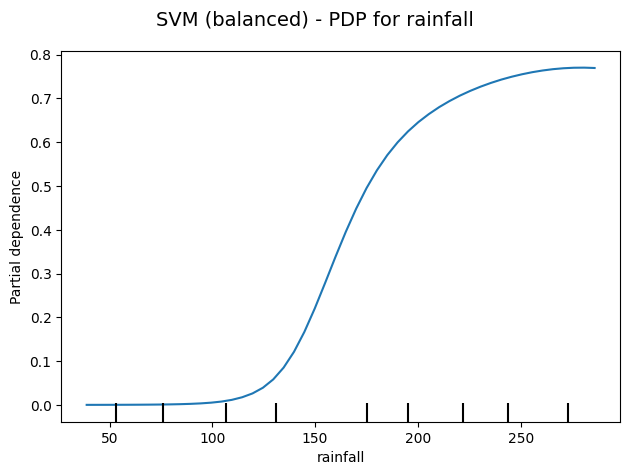

<Figure size 600x400 with 0 Axes>

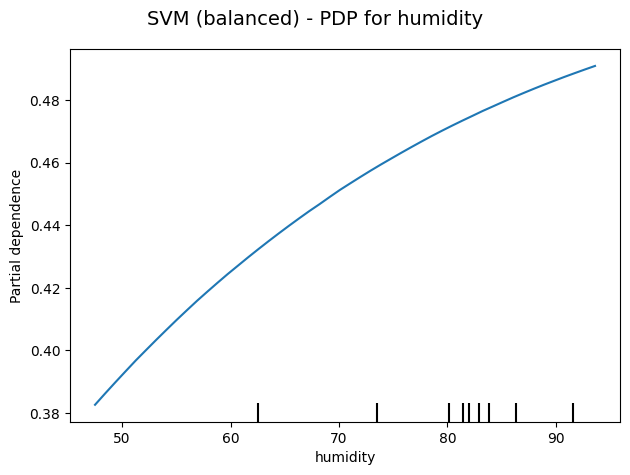

<Figure size 600x400 with 0 Axes>

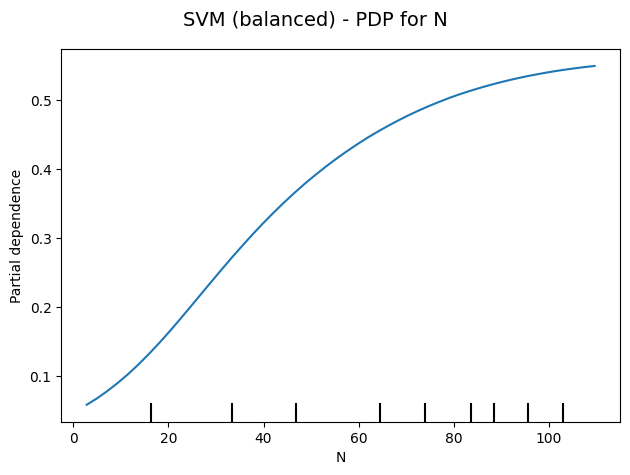


[balanced] Generating PDP for MLP...


<Figure size 600x400 with 0 Axes>

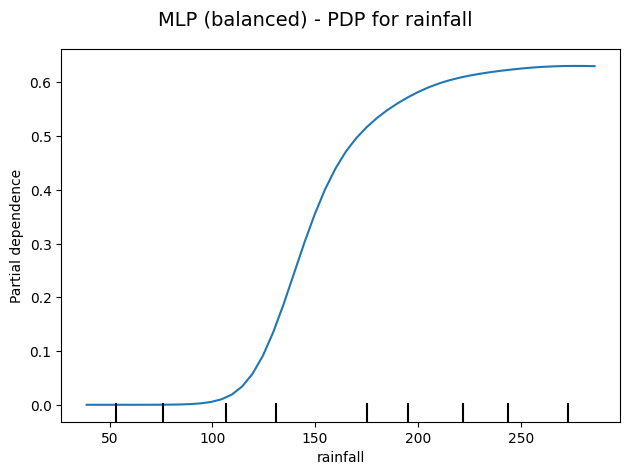

<Figure size 600x400 with 0 Axes>

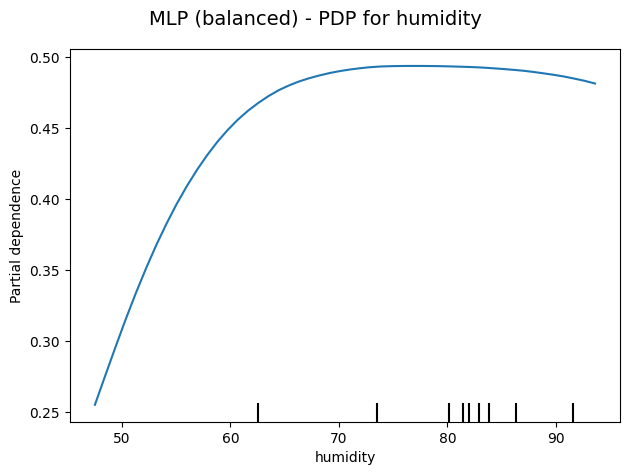

<Figure size 600x400 with 0 Axes>

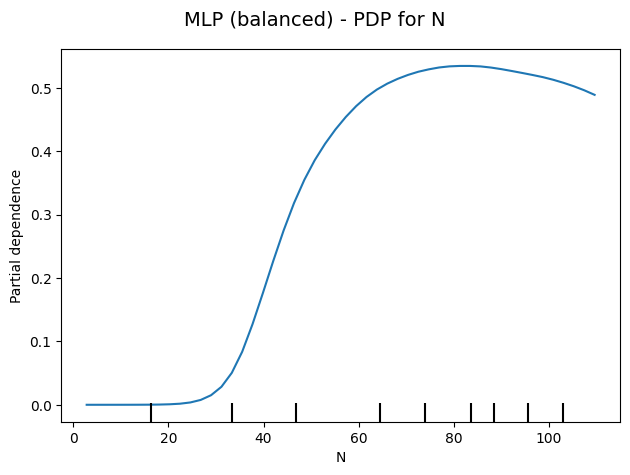


[balanced] Generating PDP for LogReg...


<Figure size 600x400 with 0 Axes>

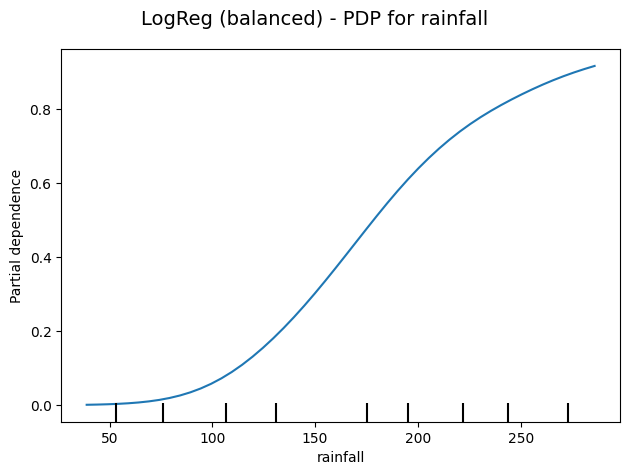

<Figure size 600x400 with 0 Axes>

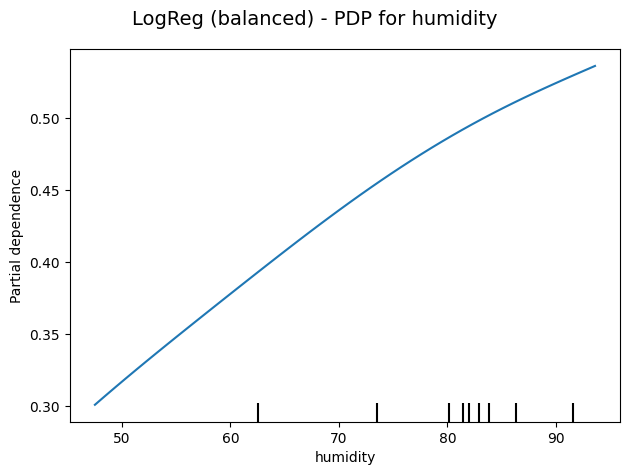

<Figure size 600x400 with 0 Axes>

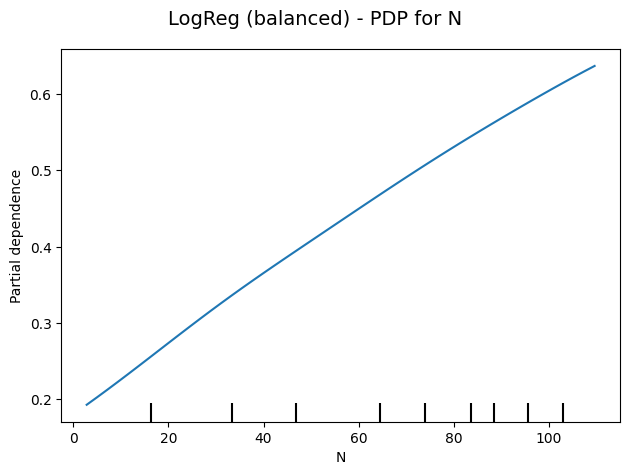


[imbalanced] Generating PDP for XGB...


<Figure size 600x400 with 0 Axes>

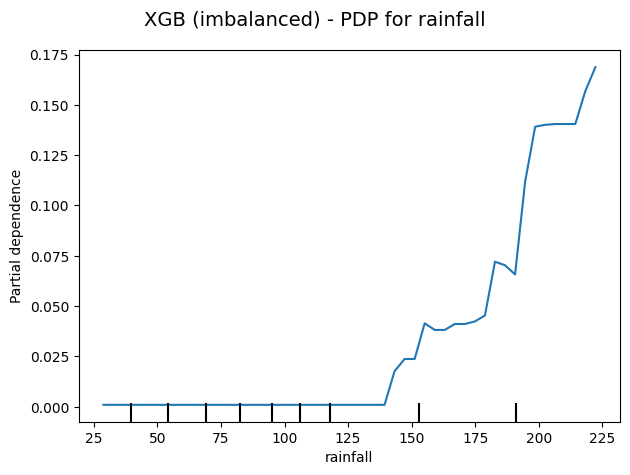

<Figure size 600x400 with 0 Axes>

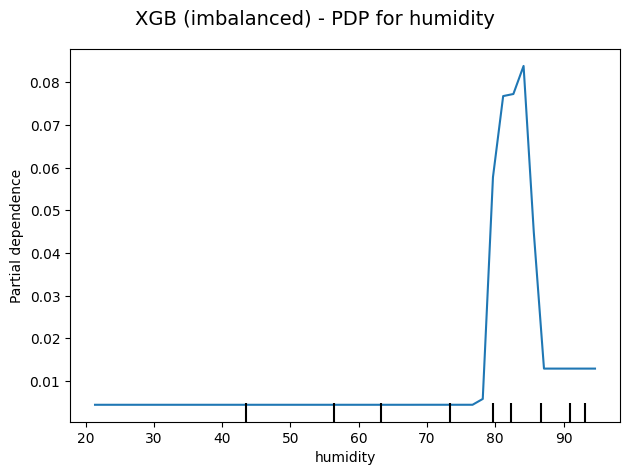

<Figure size 600x400 with 0 Axes>

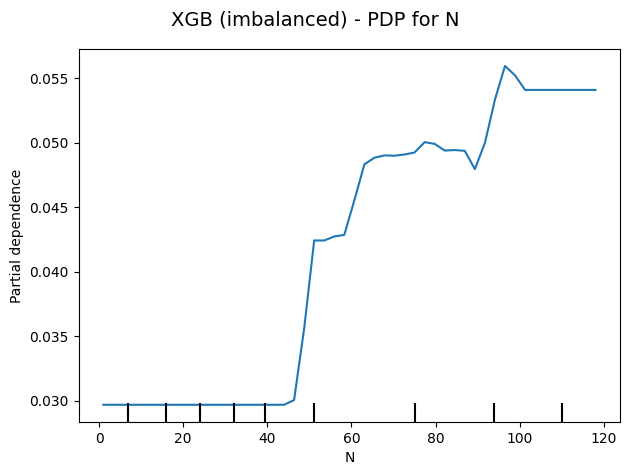


[imbalanced] Generating PDP for SVM...


<Figure size 600x400 with 0 Axes>

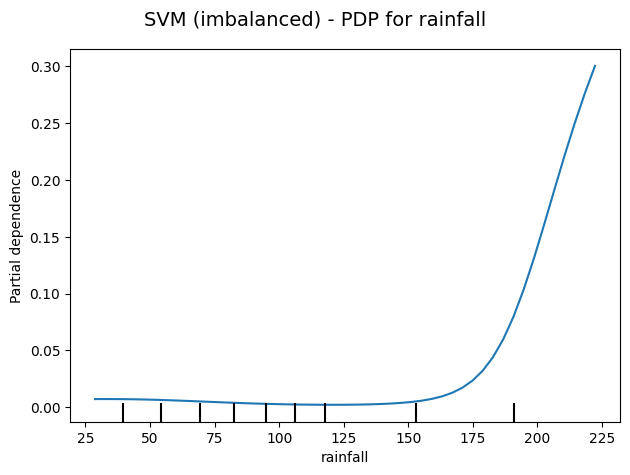

<Figure size 600x400 with 0 Axes>

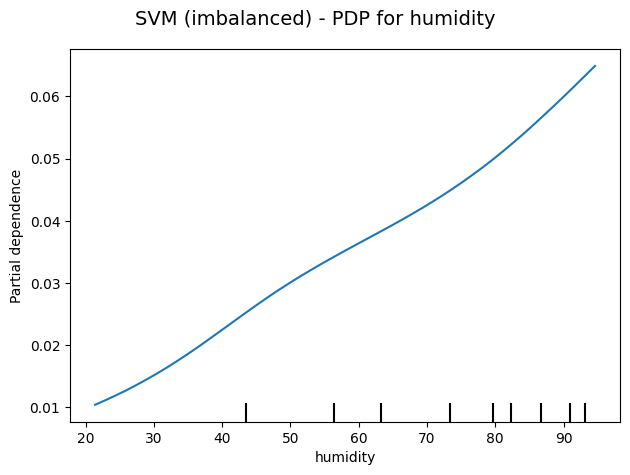

<Figure size 600x400 with 0 Axes>

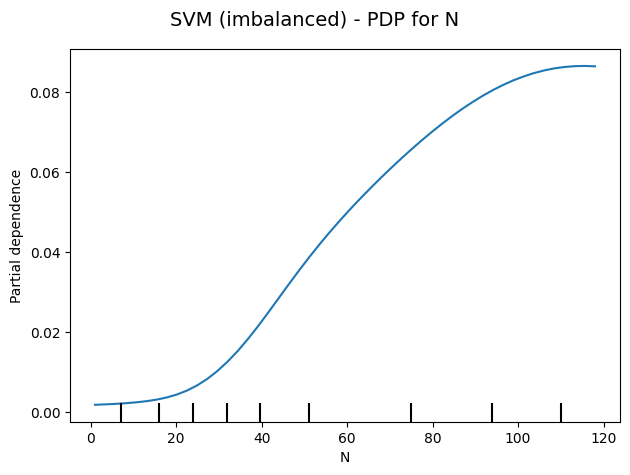


[imbalanced] Generating PDP for MLP...


<Figure size 600x400 with 0 Axes>

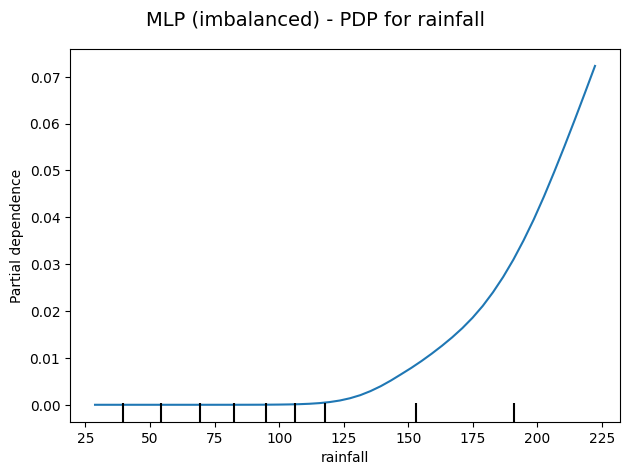

<Figure size 600x400 with 0 Axes>

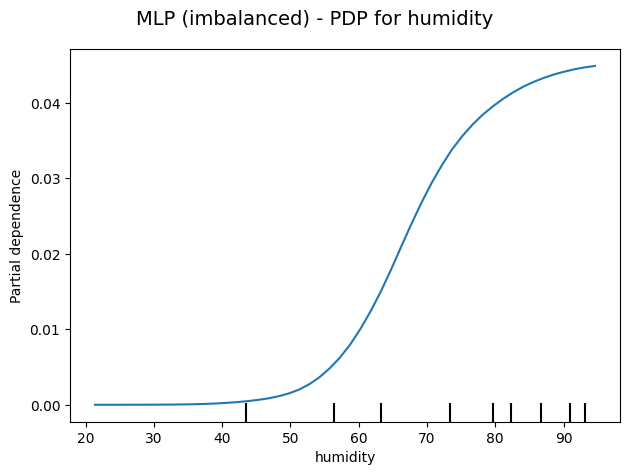

<Figure size 600x400 with 0 Axes>

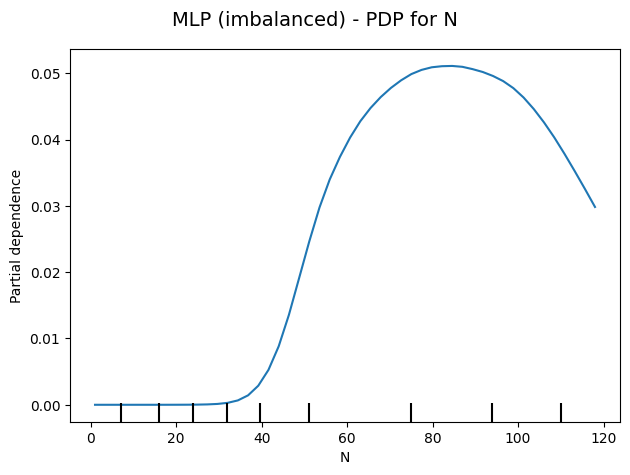


[imbalanced] Generating PDP for LogReg...


<Figure size 600x400 with 0 Axes>

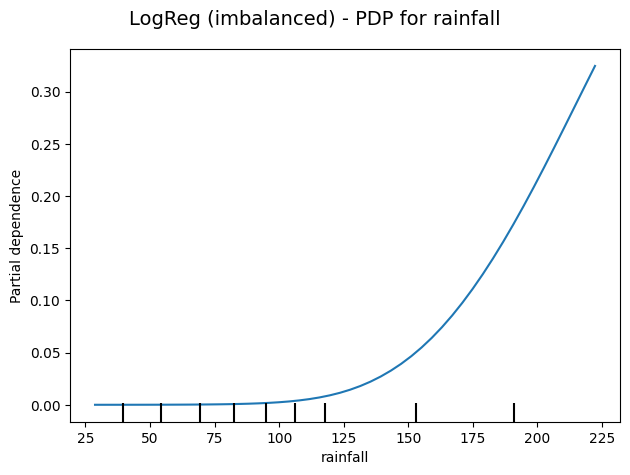

<Figure size 600x400 with 0 Axes>

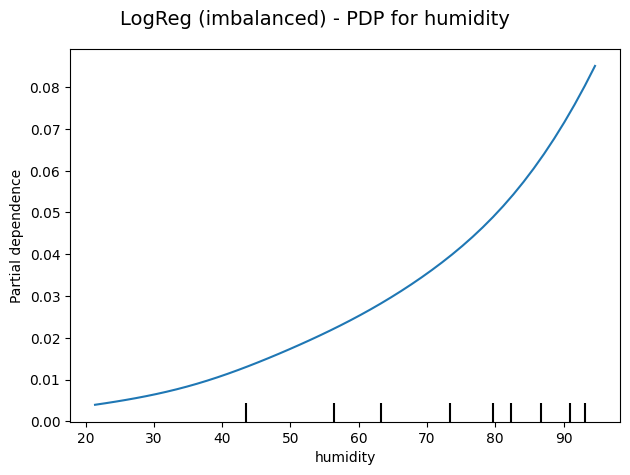

<Figure size 600x400 with 0 Axes>

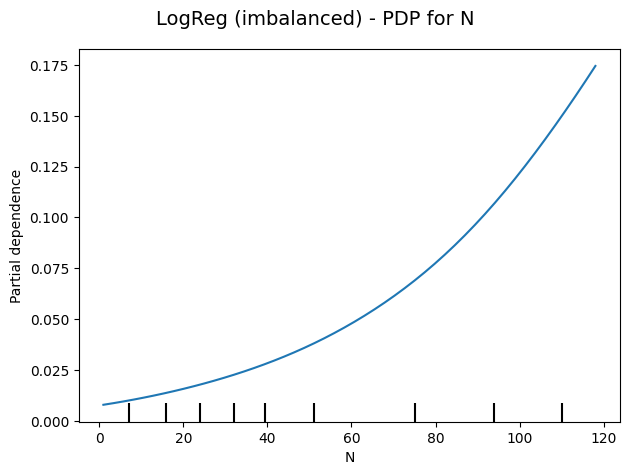

In [54]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# ----------------------
# Helper: Run PDP for a given model & dataset
# ----------------------
def run_pdp(model, X_train, X_test, y_train, y_test, model_name, dataset_case, top_features):
    print(f"\n[{dataset_case}] Generating PDP for {model_name}...")
    model.fit(X_train, y_train)

    for feat in top_features:
        plt.figure(figsize=(6, 4))
        PartialDependenceDisplay.from_estimator(
            model,
            X_test,
            [feat],
            kind="average",  # PDP
            grid_resolution=50
        )
        plt.suptitle(f"{model_name} ({dataset_case}) - PDP for {feat}", fontsize=14)
        plt.tight_layout()
        plt.show()

# ----------------------
# Select top N features from PFI
# ----------------------
N_TOP = 3
# Use balanced PFI results from earlier final_pfi_df
top_features_balanced = final_pfi_df.sort_values(by="XGB_balanced_PFI", ascending=False)["Feature"].head(N_TOP).tolist()
top_features_imbalanced = final_pfi_df.sort_values(by="XGB_imbalanced_PFI", ascending=False)["Feature"].head(N_TOP).tolist()

print(f"Top {N_TOP} Balanced Features (based on PFI): {top_features_balanced}")
print(f"Top {N_TOP} Imbalanced Features (based on PFI): {top_features_imbalanced}")

# ----------------------
# Models
# ----------------------
models = [
    (xgb_model, "XGB"),
    (svm_model, "SVM"),
    (mlp_model, "MLP"),
    (logreg_model, "LogReg")
]

# ----------------------
# Run PDP for Balanced Dataset
# ----------------------
for model, name in models:
    run_pdp(model, Xb_train, Xb_test, yb_train, yb_test, name, "balanced", top_features_balanced)

# ----------------------
# Run PDP for Imbalanced Dataset
# ----------------------
for model, name in models:
    run_pdp(model, Xi_train, Xi_test, yi_train, yi_test, name, "imbalanced", top_features_imbalanced)


ICE implementation for all 4 models


[balanced] Generating ICE for XGB...


<Figure size 600x400 with 0 Axes>

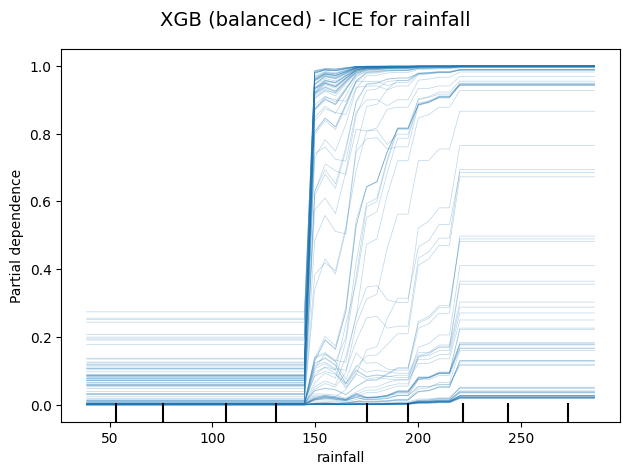

<Figure size 600x400 with 0 Axes>

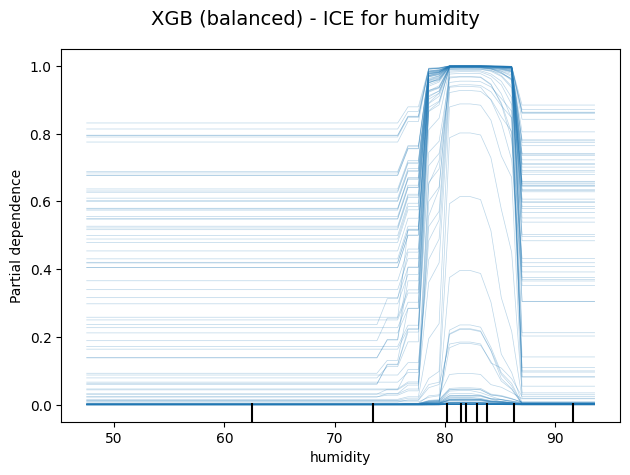

<Figure size 600x400 with 0 Axes>

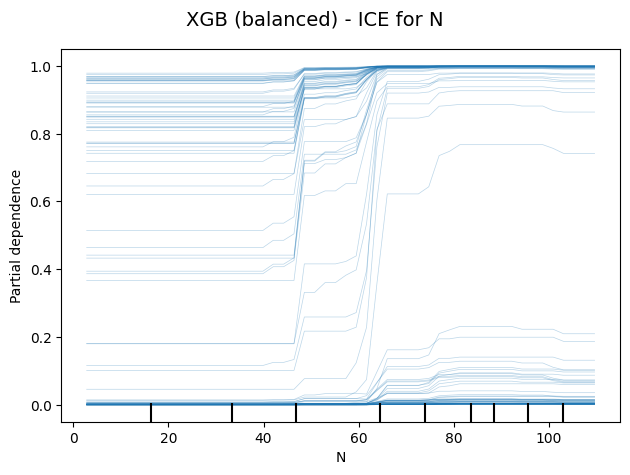


[balanced] Generating ICE for SVM...


<Figure size 600x400 with 0 Axes>

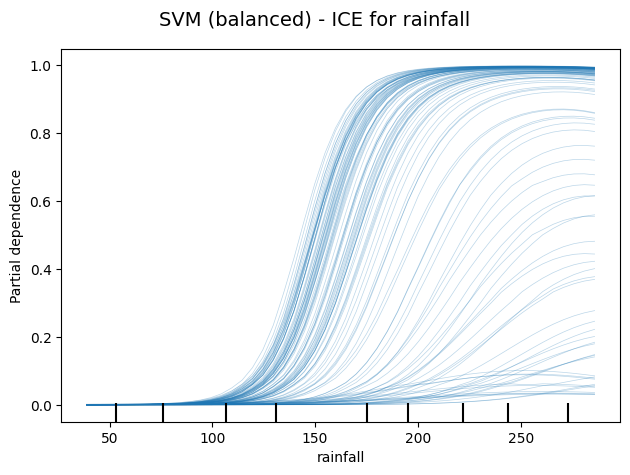

<Figure size 600x400 with 0 Axes>

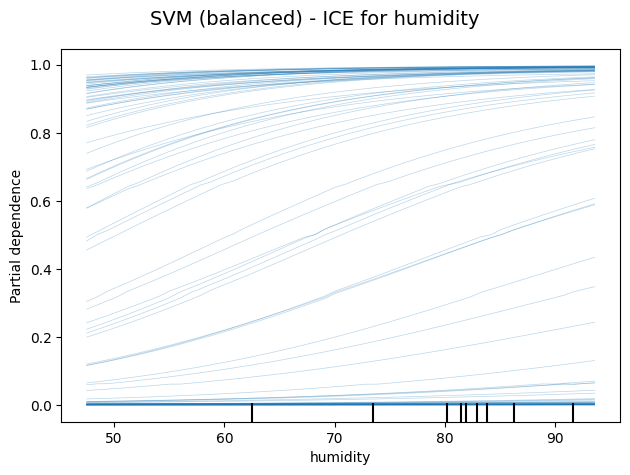

<Figure size 600x400 with 0 Axes>

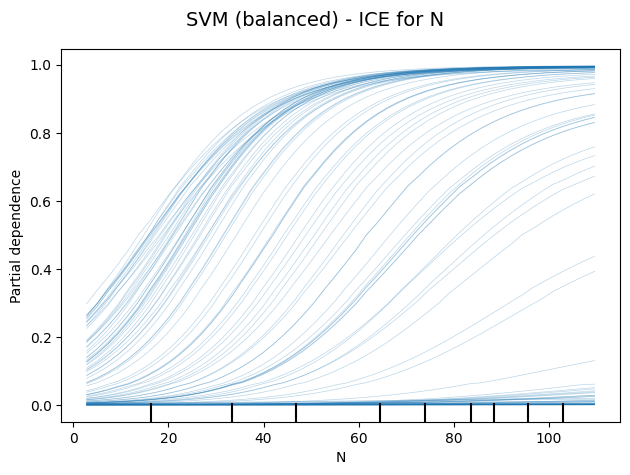


[balanced] Generating ICE for MLP...


<Figure size 600x400 with 0 Axes>

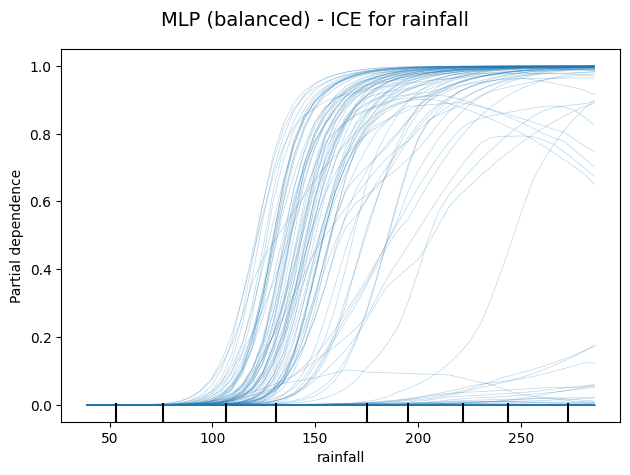

<Figure size 600x400 with 0 Axes>

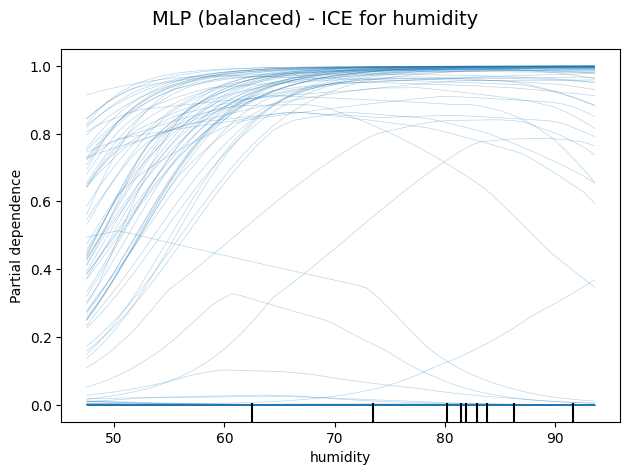

<Figure size 600x400 with 0 Axes>

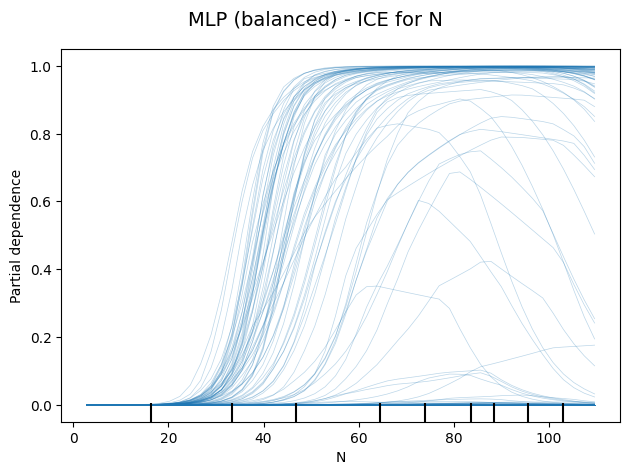


[balanced] Generating ICE for LogReg...


<Figure size 600x400 with 0 Axes>

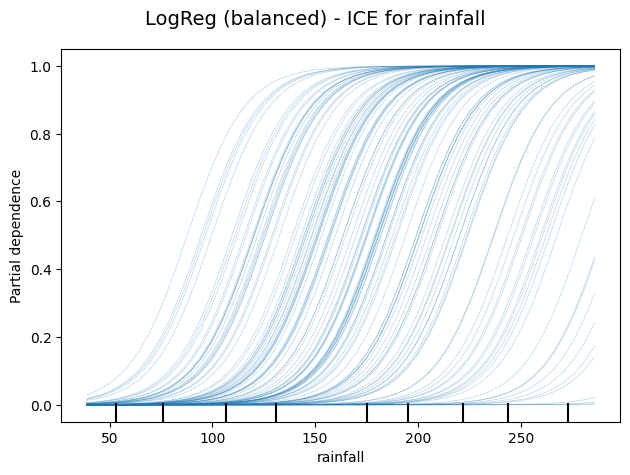

<Figure size 600x400 with 0 Axes>

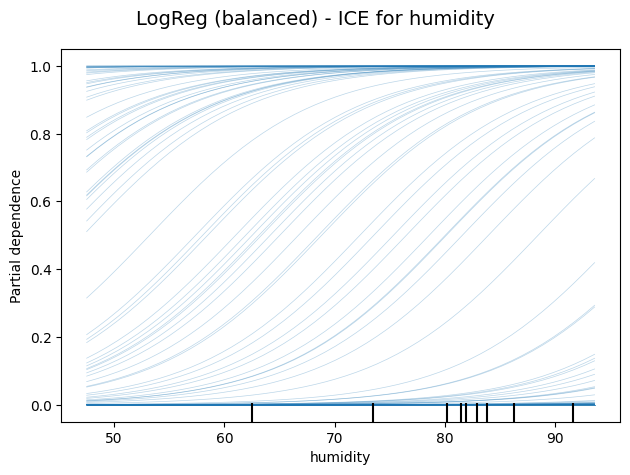

<Figure size 600x400 with 0 Axes>

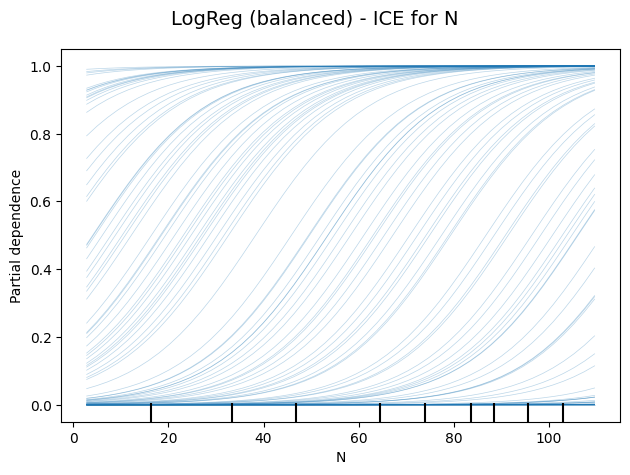


[imbalanced] Generating ICE for XGB...


<Figure size 600x400 with 0 Axes>

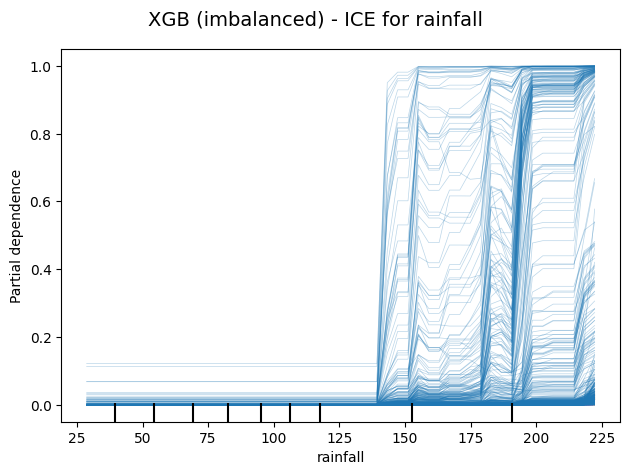

<Figure size 600x400 with 0 Axes>

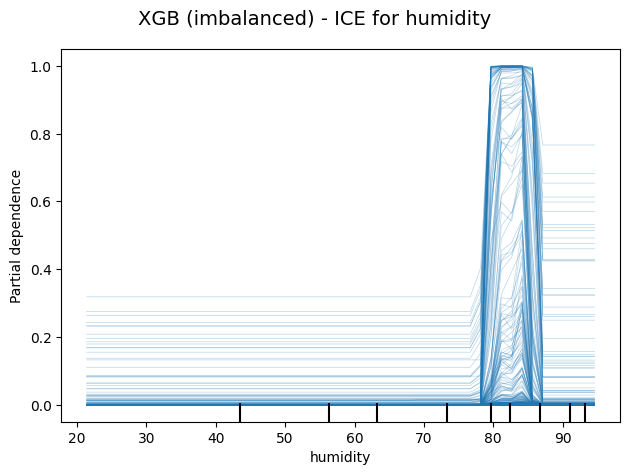

<Figure size 600x400 with 0 Axes>

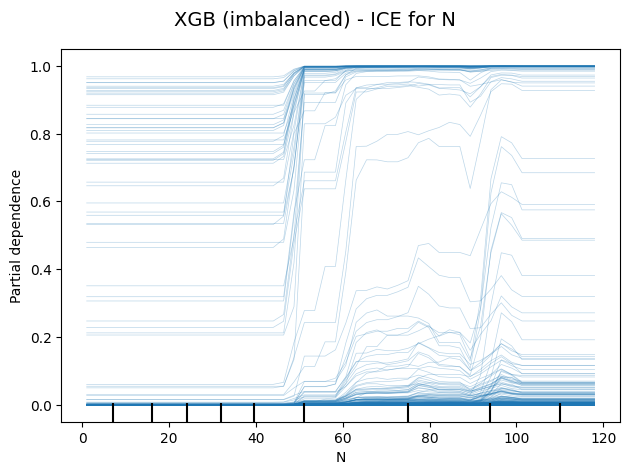


[imbalanced] Generating ICE for SVM...


<Figure size 600x400 with 0 Axes>

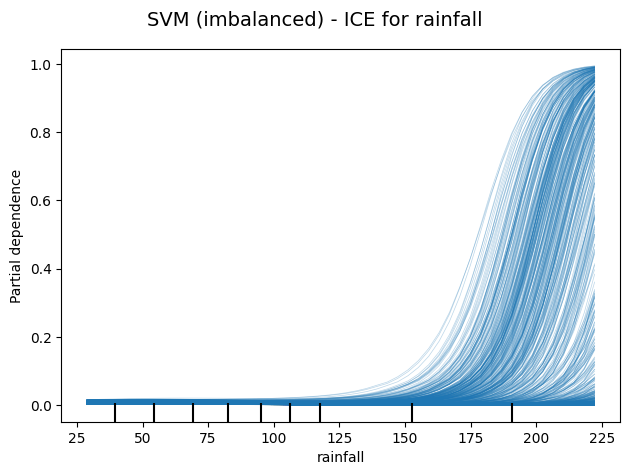

<Figure size 600x400 with 0 Axes>

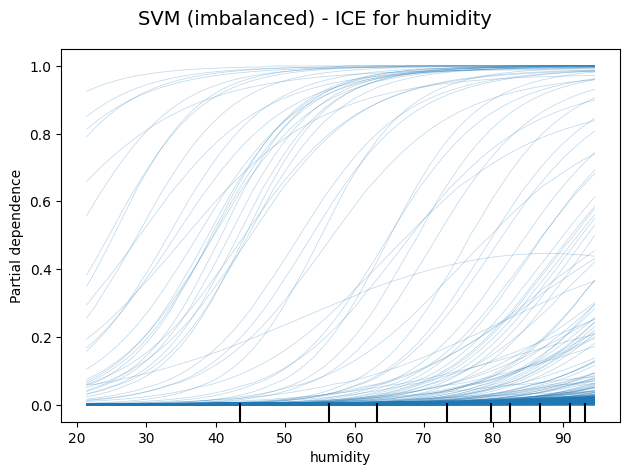

<Figure size 600x400 with 0 Axes>

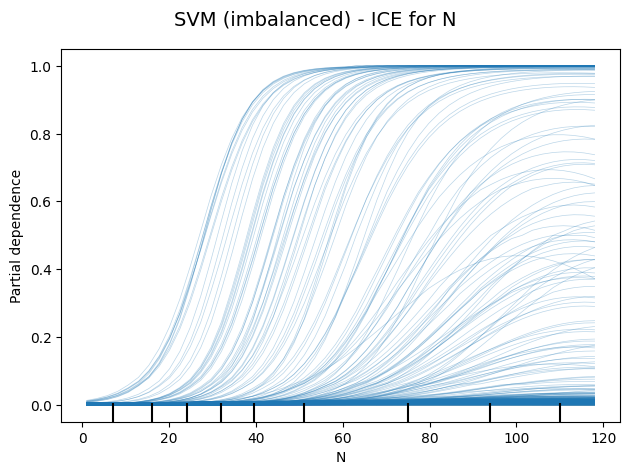


[imbalanced] Generating ICE for MLP...


<Figure size 600x400 with 0 Axes>

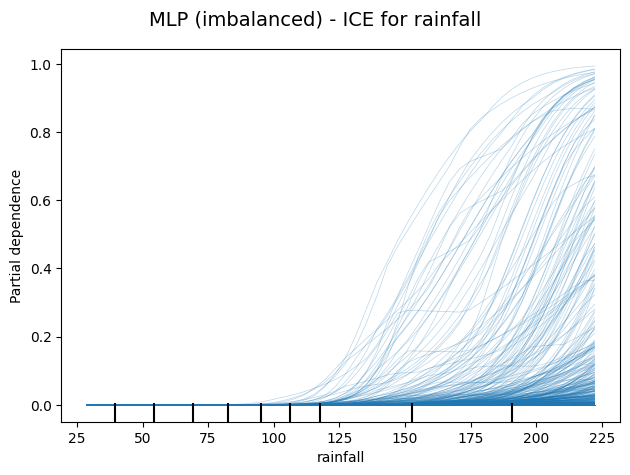

<Figure size 600x400 with 0 Axes>

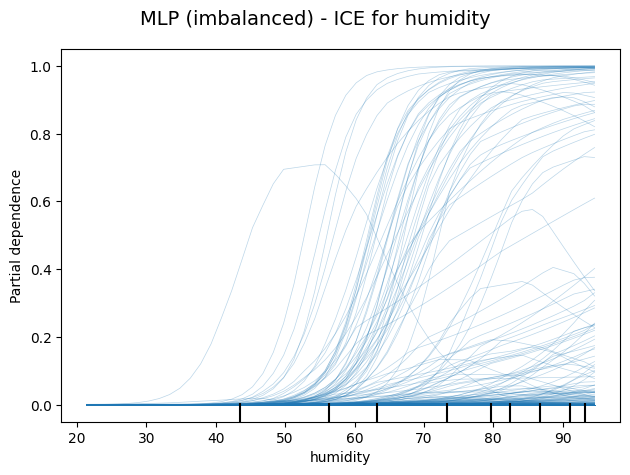

<Figure size 600x400 with 0 Axes>

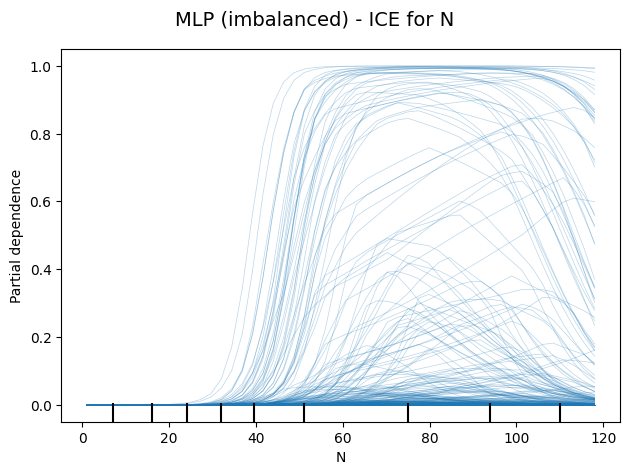


[imbalanced] Generating ICE for LogReg...


<Figure size 600x400 with 0 Axes>

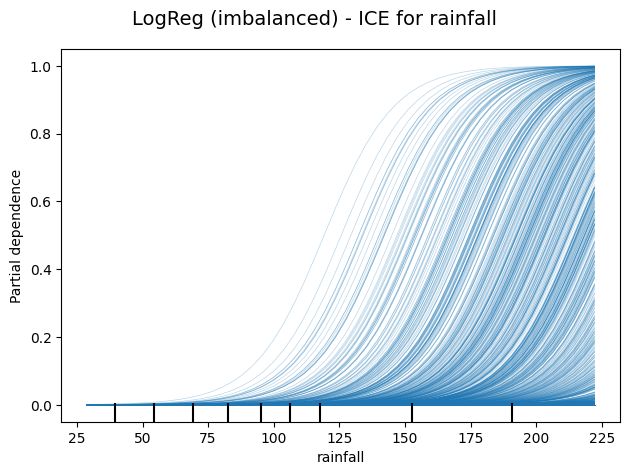

<Figure size 600x400 with 0 Axes>

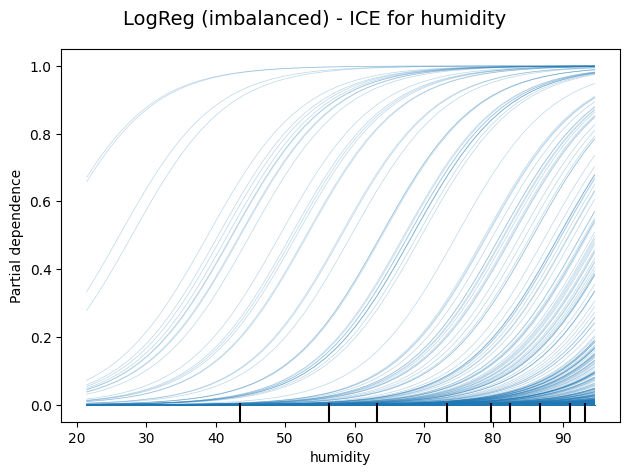

<Figure size 600x400 with 0 Axes>

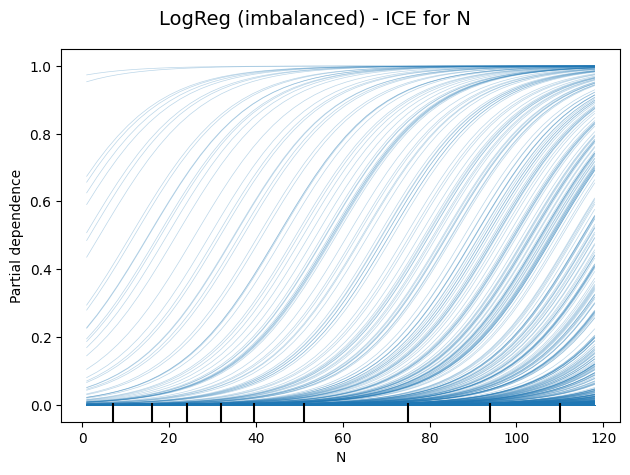

In [55]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# ----------------------
# Helper: Run ICE for a given model & dataset
# ----------------------
def run_ice(model, X_train, X_test, y_train, dataset_case, model_name, top_features):
    print(f"\n[{dataset_case}] Generating ICE for {model_name}...")
    model.fit(X_train, y_train)

    for feat in top_features:
        plt.figure(figsize=(6, 4))
        PartialDependenceDisplay.from_estimator(
            model,
            X_test,
            [feat],
            kind="individual",  # ICE instead of PDP
            grid_resolution=50
        )
        plt.suptitle(f"{model_name} ({dataset_case}) - ICE for {feat}", fontsize=14)
        plt.tight_layout()
        plt.show()

# ----------------------
# Run ICE for Balanced Dataset
# ----------------------
for model, name in models:
    run_ice(model, Xb_train, Xb_test, yb_train, "balanced", name, top_features_balanced)

# ----------------------
# Run ICE for Imbalanced Dataset
# ----------------------
for model, name in models:
    run_ice(model, Xi_train, Xi_test, yi_train, "imbalanced", name, top_features_imbalanced)


Cross validation for feature importance


=== Cross-Validation Feature Importance Stability (XGB) ===
       Feature  Mean_Importance  Std_Importance  CV_Percent
0     rainfall         0.253333        0.033160   13.089357
1     humidity         0.079583        0.020291   25.496361
2            N         0.016458        0.007552   45.884985
3  temperature         0.003333        0.004135  124.058958
4           ph        -0.001667        0.002430 -145.773797
5            P        -0.003958        0.003975 -100.414653
6            K        -0.004375        0.003975  -90.851353
Saved: /content/drive/MyDrive/rice_cv_results_balanced/XGB_cv_feature_stability.csv


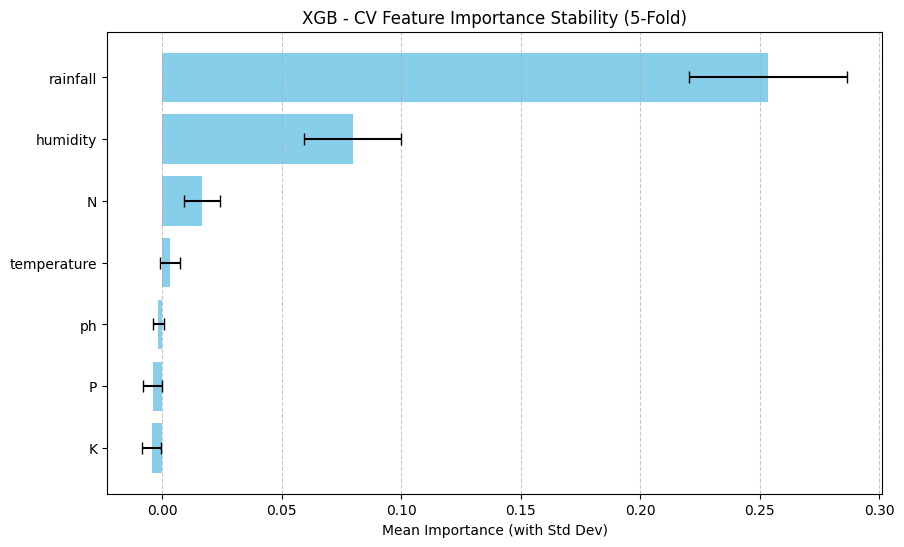

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



=== Cross-Validation Feature Importance Stability (MLP) ===
       Feature  Mean_Importance  Std_Importance  CV_Percent
0     rainfall         0.248958        0.035183   14.132105
1            N         0.149167        0.012593    8.442503
2     humidity         0.054792        0.011289   20.602612
3            P         0.041667        0.010520   25.248762
4            K         0.031042        0.009847   31.721617
5  temperature         0.030833        0.015654   50.770182
6           ph         0.003333        0.003187   95.606616
Saved: /content/drive/MyDrive/rice_cv_results_balanced/MLP_cv_feature_stability.csv


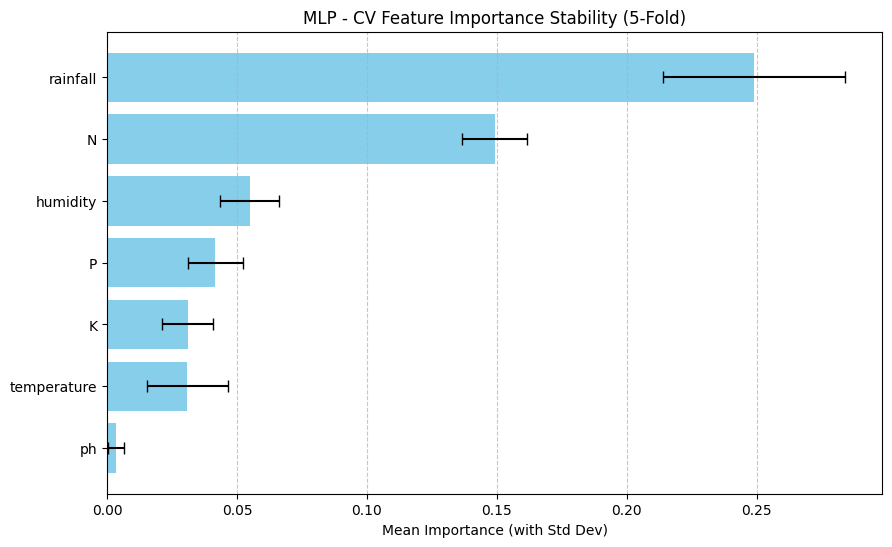


=== Cross-Validation Feature Importance Stability (SVM) ===
       Feature  Mean_Importance  Std_Importance    CV_Percent
0     rainfall     2.945833e-01        0.027468  9.324498e+00
1            N     4.229167e-02        0.016293  3.852456e+01
2            K     3.958333e-03        0.004135  1.044707e+02
3     humidity     1.250000e-03        0.007407  5.925463e+02
4           ph     0.000000e+00        0.000000           NaN
5  temperature    -2.255141e-18        0.002635 -1.168544e+17
6            P    -2.083333e-04        0.002902 -1.392839e+03
Saved: /content/drive/MyDrive/rice_cv_results_balanced/SVM_cv_feature_stability.csv


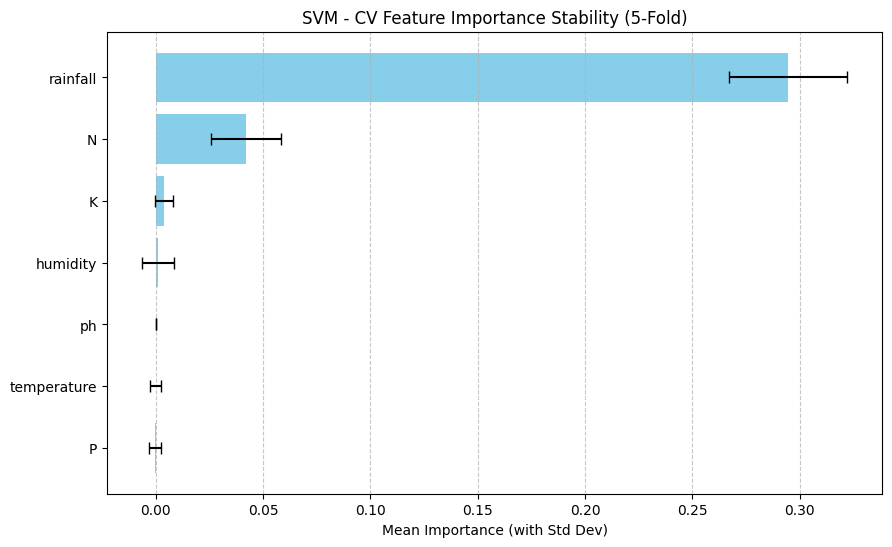


=== Cross-Validation Feature Importance Stability (LogReg) ===
       Feature  Mean_Importance  Std_Importance  CV_Percent
0     rainfall         0.326458        0.038823   11.892095
1            N         0.081042        0.014410   17.780582
2  temperature         0.033750        0.013511   40.033137
3     humidity         0.033125        0.014349   43.318680
4            K         0.006875        0.006928  100.777510
5           ph         0.005625        0.008580  152.527854
6            P         0.003958        0.004488  113.371891
Saved: /content/drive/MyDrive/rice_cv_results_balanced/LogReg_cv_feature_stability.csv


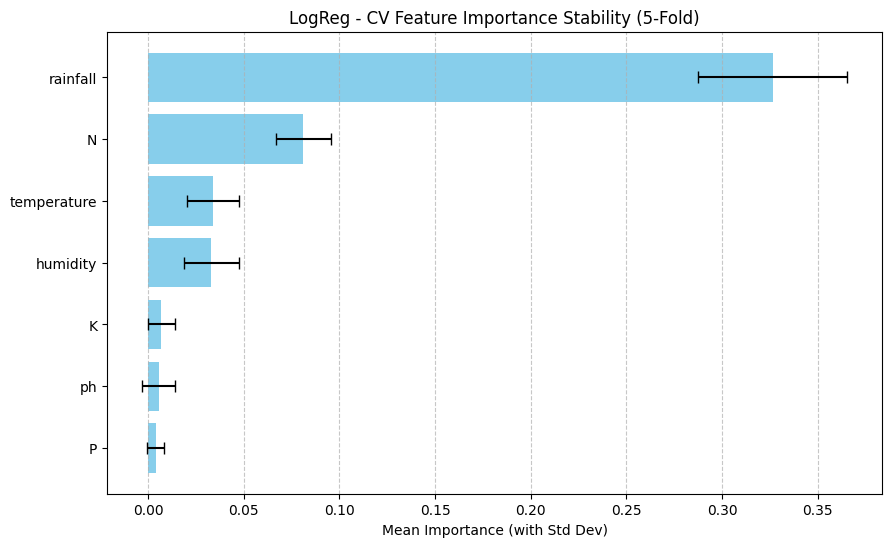


Saved combined CV importance table: /content/drive/MyDrive/rice_cv_results_balanced/cv_feature_importance_all_models.csv


In [76]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
import os

# ----------------------
# Function for CV Stability Analysis
# ----------------------
def cross_val_feature_stability(model, X, y, model_name, n_splits=5, scoring='accuracy', save_dir=None):
    """
    Run cross-validation to measure feature importance stability using permutation importance.
    Optionally save to CSV if save_dir is provided.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    feature_importances = pd.DataFrame(index=X.columns)

    fold = 1
    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Fit model
        model.fit(X_train, y_train)

        # Permutation importance
        pfi_result = permutation_importance(
            model, X_val, y_val,
            scoring=scoring,
            n_repeats=10,
            random_state=42,
            n_jobs=-1
        )

        feature_importances[f"Fold_{fold}"] = pfi_result.importances_mean
        fold += 1

    # Calculate mean, std, and coefficient of variation
    feature_importances["Mean_Importance"] = feature_importances.mean(axis=1)
    feature_importances["Std_Importance"] = feature_importances.std(axis=1)
    feature_importances["CV_Percent"] = (
        feature_importances["Std_Importance"] /
        feature_importances["Mean_Importance"].replace(0, np.nan)
    ) * 100

    # Sort by mean importance
    feature_importances = feature_importances.sort_values(by="Mean_Importance", ascending=False)
    feature_importances = feature_importances.reset_index().rename(columns={"index": "Feature"})

    # Display table
    print(f"\n=== Cross-Validation Feature Importance Stability ({model_name}) ===")
    print(feature_importances[["Feature", "Mean_Importance", "Std_Importance", "CV_Percent"]])

    # Save to CSV if requested
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        file_path = os.path.join(save_dir, f"{model_name}_cv_feature_stability.csv")
        feature_importances.to_csv(file_path, index=False)
        print(f"Saved: {file_path}")

    # Plot importance with error bars
    plt.figure(figsize=(10, 6))
    plt.barh(
        feature_importances["Feature"],
        feature_importances["Mean_Importance"],
        xerr=feature_importances["Std_Importance"],
        color="skyblue",
        ecolor="black",
        capsize=4
    )
    plt.gca().invert_yaxis()
    plt.xlabel("Mean Importance (with Std Dev)")
    plt.title(f"{model_name} - CV Feature Importance Stability ({n_splits}-Fold)")
    plt.grid(axis="x", linestyle="--", alpha=0.7)
    plt.show()

    return feature_importances

# ----------------------
# Define all models
# ----------------------
models = {
    "XGB": XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric='logloss'
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(100,), max_iter=500, random_state=42
    ),
    "SVM": SVC(
        probability=True, kernel="rbf", random_state=42
    ),
    "LogReg": LogisticRegression(
        max_iter=1000, solver="lbfgs", random_state=42
    )
}

# ----------------------
# Run stability analysis for all models & save
# ----------------------
save_directory = "/content/drive/MyDrive/rice_cv_results_balanced"
results = {}

for model_name, model in models.items():
    results[model_name] = cross_val_feature_stability(
        model, Xb_train, yb_train, model_name,
        save_dir=save_directory
    )

# ----------------------
# Create merged CSV with all Mean_Importance side-by-side
# ----------------------
merged_df = results["XGB"][["Feature", "Mean_Importance"]].rename(columns={"Mean_Importance": "XGB_CV"})

for model_name in ["SVM", "MLP", "LogReg"]:
    merged_df = merged_df.merge(
        results[model_name][["Feature", "Mean_Importance"]].rename(columns={"Mean_Importance": f"{model_name}_CV"}),
        on="Feature"
    )

# Save combined table
combined_path = os.path.join(save_directory, "cv_feature_importance_all_models.csv")
merged_df.to_csv(combined_path, index=False)
print(f"\nSaved combined CV importance table: {combined_path}")


Final feature consensus ranking

In [77]:
import pandas as pd
import os

# === File paths ===
files = {
    "SHAP Balanced": "/content/drive/MyDrive/rice_shap_feature_importance_balanced.csv",
    "LogReg SHAP LIME": "/content/drive/MyDrive/rice_logreg_shap_lime.csv",
    "PFI": "/content/drive/MyDrive/rice_pfi_feature_importance.csv",
    "CV Merged": "/content/drive/MyDrive/rice_cv_results_balanced/cv_feature_importance_all_models.csv"  # optional
}

print("=== Checking CSV Column Names & Previews ===")
for name, path in files.items():
    print(f"\n{name}:")
    if os.path.exists(path):
        try:
            df = pd.read_csv(path, nrows=5)
            print("Columns:", df.columns.tolist())
            if "Unnamed: 0" in df.columns:
                print("Note: 'Unnamed: 0' likely index column from previous save.")
            print("Preview:\n", df.head(2))
        except Exception as e:
            print(f"Error reading {path}: {e}")
    else:
        print(f"File not found: {path}")

# === Check in-memory CV results if available ===
print("\n=== Checking In-Memory CV Results ===")
for var_name in ["cv_results", "results"]:
    if var_name in globals():
        var_obj = globals()[var_name]
        if isinstance(var_obj, dict):
            for model in ["XGB", "SVM", "MLP", "LogReg"]:
                if model in var_obj:
                    print(f"\n{var_name} -> {model} columns:")
                    print(var_obj[model].columns.tolist())
                else:
                    print(f"{var_name} -> {model} not found in dict.")
        else:
            print(f"{var_name} exists but is not a dict.")
    else:
        print(f"{var_name} not defined.")


=== Checking CSV Column Names & Previews ===

SHAP Balanced:
Columns: ['Unnamed: 0', 'N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Note: 'Unnamed: 0' likely index column from previous save.
Preview:
      Unnamed: 0                        N                        P  \
0  RandomForest  [0.09351736 0.09351736]  [0.02857916 0.02857916]   
1       XGBoost        1.639876127243042       0.4120810329914093   

                         K              temperature                 humidity  \
0  [0.07108152 0.07108152]  [0.02815507 0.02815507]  [0.10305672 0.10305672]   
1      0.29005706310272217       0.8016512393951416       1.6867730617523193   

                      ph                 rainfall  
0  [0.0086885 0.0086885]  [0.19299976 0.19299976]  
1    0.04939859360456467        3.255645751953125  

LogReg SHAP LIME:
Columns: ['Feature', 'LogReg_balanced_SHAP', 'LogReg_balanced_LIME', 'LogReg_imbalanced_SHAP', 'LogReg_imbalanced_LIME']
Preview:
   Feature  LogReg_balanced_SHAP

In [78]:
import pandas as pd
import numpy as np
import ast

# ==============================
# 1. Load SHAP Balanced
# ==============================
shap_bal_path = "/content/drive/MyDrive/rice_shap_feature_importance_balanced.csv"
shap_raw = pd.read_csv(shap_bal_path)

# Drop 'Unnamed: 0' if present
if 'Unnamed: 0' in shap_raw.columns:
    shap_raw = shap_raw.rename(columns={'Unnamed: 0': 'Model'})

# ==============================
# 2. Keep only relevant models (XGBoost, SVM, MLP)
# ==============================
shap_raw = shap_raw[shap_raw['Model'].isin(['XGBoost', 'SVM', 'MLP'])]

# ==============================
# 3. Function to parse and average list-like values
# ==============================
def extract_value(val):
    # If value is string like "[0.0935 0.0935]"
    if isinstance(val, str) and val.startswith("["):
        try:
            arr = np.array(ast.literal_eval(val))
            return float(np.mean(np.abs(arr)))
        except:
            return np.nan
    # If already list or array
    elif isinstance(val, (list, np.ndarray)):
        return float(np.mean(np.abs(val)))
    # If scalar
    else:
        try:
            return float(val)
        except:
            return np.nan

# ==============================
# 4. Apply parsing to all feature columns
# ==============================
feature_cols = [col for col in shap_raw.columns if col != 'Model']
for col in feature_cols:
    shap_raw[col] = shap_raw[col].apply(extract_value)

# ==============================
# 5. Transpose so features become rows
# ==============================
shap_df = shap_raw.set_index('Model').T.reset_index()
shap_df = shap_df.rename(columns={'index': 'Feature',
                                  'XGBoost': 'XGB_SHAP',
                                  'SVM': 'SVM_SHAP',
                                  'MLP': 'MLP_SHAP'})

# ==============================
# 6. Normalize SHAP columns so each sums to 1
# ==============================
for col in ['XGB_SHAP', 'SVM_SHAP', 'MLP_SHAP']:
    shap_df[col] = shap_df[col] / shap_df[col].sum()

# ==============================
# 7. Save as partial merge table for now
# ==============================
partial_merge_path = "/content/drive/MyDrive/rice_feature_importance_partial_merge.csv"
shap_df.to_csv(partial_merge_path, index=False)

print("\n=== SHAP Balanced Parsed & Normalized ===")
print(shap_df.head())
print(f"\nPartial merge table saved to: {partial_merge_path}")



=== SHAP Balanced Parsed & Normalized ===
Model      Feature  XGB_SHAP  SVM_SHAP  MLP_SHAP
0                N  0.201571       NaN       NaN
1                P  0.050652       NaN       NaN
2                K  0.035653       NaN       NaN
3      temperature  0.098538       NaN       NaN
4         humidity  0.207335       NaN       NaN

Partial merge table saved to: /content/drive/MyDrive/rice_feature_importance_partial_merge.csv


In [80]:
import shap
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# ==============================
# 1. Load Balanced Rice Dataset
# ==============================
df = pd.read_csv('/content/drive/MyDrive/Crop_recommendation_expanded.csv')
df['target'] = (df['label'] == 'rice').astype(int)

# Balanced dataset creation
df_rice = df[df['target'] == 1]
df_not_rice = df[df['target'] == 0].sample(n=len(df_rice), random_state=42)
df_bal = pd.concat([df_rice, df_not_rice]).sample(frac=1, random_state=42).reset_index(drop=True)

X_bal = df_bal.drop(columns=['label', 'target'])
y_bal = df_bal['target']

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=42
)

# ==============================
# 2. Train SVM model
# ==============================
print("[Balanced] Training SVM...")
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(Xb_train, yb_train)

# ==============================
# 3. SHAP for SVM (KernelExplainer)
# ==============================
print("[Balanced] Computing SHAP values for SVM...")
X_train_np = np.array(Xb_train)
X_test_np = np.array(Xb_test)

# Sample fewer background points for speed
background = shap.sample(X_train_np, 50, random_state=42)

explainer = shap.KernelExplainer(svm_model.predict_proba, background)

# Limit nsamples for speed — adjust if needed
shap_values_all_classes = explainer.shap_values(X_test_np, nsamples=100)

# Ensure shape is (n_classes, n_samples, n_features)
if isinstance(shap_values_all_classes, list):
    shap_values_all_classes = np.array(shap_values_all_classes)

if shap_values_all_classes.shape[0] != 2:
    shap_values_all_classes = np.transpose(shap_values_all_classes, (2, 0, 1))

# Combine SHAP values across classes → absolute mean
shap_values_combined = np.sum(np.abs(shap_values_all_classes), axis=0)
mean_abs_shap = np.abs(shap_values_combined).mean(axis=0)

assert mean_abs_shap.shape[0] == len(Xb_train.columns), "Feature count mismatch!"

# ==============================
# 4. Prepare dataframe for merge
# ==============================
svm_shap_df = pd.DataFrame({
    'Feature': Xb_train.columns,
    'SVM_SHAP': mean_abs_shap
})

# Normalize
svm_shap_df['SVM_SHAP'] = svm_shap_df['SVM_SHAP'] / svm_shap_df['SVM_SHAP'].sum()

# ==============================
# 5. Merge into partial SHAP Balanced table (cleaning old columns)
# ==============================
partial_merge_path = "/content/drive/MyDrive/rice_feature_importance_partial_merge.csv"
partial_df = pd.read_csv(partial_merge_path)

# Drop any existing SVM_SHAP-related columns
partial_df = partial_df.drop(columns=[col for col in partial_df.columns if col.startswith("SVM_SHAP")], errors="ignore")

# Merge SVM SHAP cleanly
merged_df = partial_df.merge(svm_shap_df, on='Feature', how='left')

# Save updated partial table
merged_df.to_csv(partial_merge_path, index=False)

print("\n=== Updated Partial Merge Table with SVM_SHAP ===")
print(merged_df.head())
print(f"\nUpdated partial table saved to: {partial_merge_path}")


[Balanced] Training SVM...
[Balanced] Computing SHAP values for SVM...


  0%|          | 0/120 [00:00<?, ?it/s]


=== Updated Partial Merge Table with SVM_SHAP ===
       Feature  XGB_SHAP  MLP_SHAP  SVM_SHAP
0            N  0.201571       NaN  0.241603
1            P  0.050652       NaN  0.025938
2            K  0.035653       NaN  0.057532
3  temperature  0.098538       NaN  0.012132
4     humidity  0.207335       NaN  0.058969

Updated partial table saved to: /content/drive/MyDrive/rice_feature_importance_partial_merge.csv


In [81]:
import shap
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

# ==============================
# 1. Load Balanced Rice Dataset
# ==============================
df = pd.read_csv('/content/drive/MyDrive/Crop_recommendation_expanded.csv')
df['target'] = (df['label'] == 'rice').astype(int)

# Balanced dataset creation
df_rice = df[df['target'] == 1]
df_not_rice = df[df['target'] == 0].sample(n=len(df_rice), random_state=42)
df_bal = pd.concat([df_rice, df_not_rice]).sample(frac=1, random_state=42).reset_index(drop=True)

X_bal = df_bal.drop(columns=['label', 'target'])
y_bal = df_bal['target']

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=42
)

# ==============================
# 2. Train MLP model
# ==============================
print("[Balanced] Training MLP...")
mlp_model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
mlp_model.fit(Xb_train, yb_train)

# ==============================
# 3. SHAP for MLP (KernelExplainer)
# ==============================
print("[Balanced] Computing SHAP values for MLP...")
X_train_np = np.array(Xb_train)
X_test_np = np.array(Xb_test)

# Sample fewer background points for speed
background = shap.sample(X_train_np, 50, random_state=42)

explainer = shap.KernelExplainer(mlp_model.predict_proba, background)

# Limit nsamples for speed — adjust if needed
shap_values_all_classes = explainer.shap_values(X_test_np, nsamples=100)

# Ensure shape is (n_classes, n_samples, n_features)
if isinstance(shap_values_all_classes, list):
    shap_values_all_classes = np.array(shap_values_all_classes)

if shap_values_all_classes.shape[0] != 2:
    shap_values_all_classes = np.transpose(shap_values_all_classes, (2, 0, 1))

# Combine SHAP values across classes → absolute mean
shap_values_combined = np.sum(np.abs(shap_values_all_classes), axis=0)
mean_abs_shap = np.abs(shap_values_combined).mean(axis=0)

assert mean_abs_shap.shape[0] == len(Xb_train.columns), "Feature count mismatch!"

# ==============================
# 4. Prepare dataframe for merge
# ==============================
mlp_shap_df = pd.DataFrame({
    'Feature': Xb_train.columns,
    'MLP_SHAP': mean_abs_shap
})

# Normalize
mlp_shap_df['MLP_SHAP'] = mlp_shap_df['MLP_SHAP'] / mlp_shap_df['MLP_SHAP'].sum()

# ==============================
# 5. Merge into partial SHAP Balanced table (cleaning old columns)
# ==============================
partial_merge_path = "/content/drive/MyDrive/rice_feature_importance_partial_merge.csv"
partial_df = pd.read_csv(partial_merge_path)

# Drop any existing MLP_SHAP-related columns (_x, _y, etc.)
partial_df = partial_df.drop(columns=[col for col in partial_df.columns if col.startswith("MLP_SHAP")], errors="ignore")

# Merge MLP SHAP cleanly
merged_df = partial_df.merge(mlp_shap_df, on='Feature', how='left')

# Save updated partial table
merged_df.to_csv(partial_merge_path, index=False)

print("\n=== Updated Partial Merge Table with MLP_SHAP ===")
print(merged_df.head())
print(f"\nUpdated partial table saved to: {partial_merge_path}")


[Balanced] Training MLP...
[Balanced] Computing SHAP values for MLP...


  0%|          | 0/120 [00:00<?, ?it/s]


=== Updated Partial Merge Table with MLP_SHAP ===
       Feature  XGB_SHAP  SVM_SHAP  MLP_SHAP
0            N  0.201571  0.241603  0.274728
1            P  0.050652  0.025938  0.084106
2            K  0.035653  0.057532  0.041510
3  temperature  0.098538  0.012132  0.099050
4     humidity  0.207335  0.058969  0.079865

Updated partial table saved to: /content/drive/MyDrive/rice_feature_importance_partial_merge.csv


In [82]:
import shap
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# ==============================
# 1. Load Balanced Rice Dataset
# ==============================
df = pd.read_csv('/content/drive/MyDrive/Crop_recommendation_expanded.csv')
df['target'] = (df['label'] == 'rice').astype(int)

# Balanced dataset creation
df_rice = df[df['target'] == 1]
df_not_rice = df[df['target'] == 0].sample(n=len(df_rice), random_state=42)
df_bal = pd.concat([df_rice, df_not_rice]).sample(frac=1, random_state=42).reset_index(drop=True)

X_bal = df_bal.drop(columns=['label', 'target'])
y_bal = df_bal['target']

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=42
)

# ==============================
# 2. Train Logistic Regression model
# ==============================
print("[Balanced] Training Logistic Regression...")
logreg_model = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42)
logreg_model.fit(Xb_train, yb_train)

# ==============================
# 3. SHAP for LogReg (KernelExplainer)
# ==============================
print("[Balanced] Computing SHAP values for Logistic Regression...")
X_train_np = np.array(Xb_train)
X_test_np = np.array(Xb_test)

# Sample fewer background points for speed
background = shap.sample(X_train_np, 50, random_state=42)

explainer = shap.KernelExplainer(logreg_model.predict_proba, background)

# Limit nsamples for speed — adjust if needed
shap_values_all_classes = explainer.shap_values(X_test_np, nsamples=100)

# Ensure shape is (n_classes, n_samples, n_features)
if isinstance(shap_values_all_classes, list):
    shap_values_all_classes = np.array(shap_values_all_classes)

if shap_values_all_classes.shape[0] != 2:
    shap_values_all_classes = np.transpose(shap_values_all_classes, (2, 0, 1))

# Combine SHAP values across classes → absolute mean
shap_values_combined = np.sum(np.abs(shap_values_all_classes), axis=0)
mean_abs_shap = np.abs(shap_values_combined).mean(axis=0)

assert mean_abs_shap.shape[0] == len(Xb_train.columns), "Feature count mismatch!"

# ==============================
# 4. Prepare dataframe for merge
# ==============================
logreg_shap_df = pd.DataFrame({
    'Feature': Xb_train.columns,
    'LogReg_SHAP': mean_abs_shap
})

# Normalize
logreg_shap_df['LogReg_SHAP'] = logreg_shap_df['LogReg_SHAP'] / logreg_shap_df['LogReg_SHAP'].sum()

# ==============================
# 5. Merge into partial SHAP Balanced table (cleaning old columns)
# ==============================
partial_merge_path = "/content/drive/MyDrive/rice_feature_importance_partial_merge.csv"
partial_df = pd.read_csv(partial_merge_path)

# Drop any existing LogReg_SHAP-related columns (_x, _y, etc.)
partial_df = partial_df.drop(columns=[col for col in partial_df.columns if col.startswith("LogReg_SHAP")], errors="ignore")

# Merge LogReg SHAP cleanly
merged_df = partial_df.merge(logreg_shap_df, on='Feature', how='left')

# Save updated partial table
merged_df.to_csv(partial_merge_path, index=False)

print("\n=== Updated Partial Merge Table with LogReg_SHAP ===")
print(merged_df.head())
print(f"\nUpdated partial table saved to: {partial_merge_path}")


[Balanced] Training Logistic Regression...
[Balanced] Computing SHAP values for Logistic Regression...


  0%|          | 0/120 [00:00<?, ?it/s]


=== Updated Partial Merge Table with LogReg_SHAP ===
       Feature  XGB_SHAP  SVM_SHAP  MLP_SHAP  LogReg_SHAP
0            N  0.201571  0.241603  0.274728     0.188698
1            P  0.050652  0.025938  0.084106     0.045942
2            K  0.035653  0.057532  0.041510     0.023577
3  temperature  0.098538  0.012132  0.099050     0.101586
4     humidity  0.207335  0.058969  0.079865     0.104984

Updated partial table saved to: /content/drive/MyDrive/rice_feature_importance_partial_merge.csv


In [83]:
import pandas as pd

# ==============================
# 1. Load PFI Balanced CSV
# ==============================
pfi_path = "/content/drive/MyDrive/rice_pfi_feature_importance.csv"
pfi_df = pd.read_csv(pfi_path)

# Keep only balanced PFI columns
pfi_bal = pfi_df[[
    "Feature",
    "XGB_balanced_PFI",
    "SVM_balanced_PFI",
    "MLP_balanced_PFI",
    "LogReg_balanced_PFI"
]].copy()

# Rename columns for final table
pfi_bal.columns = ["Feature", "XGB_PFI", "SVM_PFI", "MLP_PFI", "LogReg_PFI"]

# Normalize each PFI column
for col in ["XGB_PFI", "SVM_PFI", "MLP_PFI", "LogReg_PFI"]:
    pfi_bal[col] = pfi_bal[col] / pfi_bal[col].sum()

# ==============================
# 2. Load partial merge table & clean old PFI columns
# ==============================
partial_merge_path = "/content/drive/MyDrive/rice_feature_importance_partial_merge.csv"
partial_df = pd.read_csv(partial_merge_path)

# Drop any old PFI columns (_x, _y, or old runs)
partial_df = partial_df.drop(
    columns=[col for col in partial_df.columns if col.endswith("_PFI")],
    errors="ignore"
)

# ==============================
# 3. Merge PFI into partial table
# ==============================
merged_df = partial_df.merge(pfi_bal, on="Feature", how="left")

# Save updated partial table
merged_df.to_csv(partial_merge_path, index=False)

print("\n=== Updated Partial Merge Table with PFI Columns ===")
print(merged_df.head())
print(f"\nUpdated partial table saved to: {partial_merge_path}")



=== Updated Partial Merge Table with PFI Columns ===
       Feature  XGB_SHAP  SVM_SHAP  MLP_SHAP  LogReg_SHAP   XGB_PFI   SVM_PFI  \
0            N  0.201571  0.241603  0.274728     0.188698  0.084967  0.236246   
1            P  0.050652  0.025938  0.084106     0.045942  0.002179  0.014563   
2            K  0.035653  0.057532  0.041510     0.023577  0.006536  0.046926   
3  temperature  0.098538  0.012132  0.099050     0.101586  0.000000  0.008091   
4     humidity  0.207335  0.058969  0.079865     0.104984  0.278867  0.019417   

    MLP_PFI  LogReg_PFI  
0  0.257343    0.182048  
1  0.107692    0.029077  
2  0.089510    0.029077  
3  0.036364    0.092288  
4  0.046154    0.082174  

Updated partial table saved to: /content/drive/MyDrive/rice_feature_importance_partial_merge.csv


In [84]:
import pandas as pd

# ==============================
# 1. Load CV Balanced CSV
# ==============================
cv_path = "/content/drive/MyDrive/rice_cv_results_balanced/cv_feature_importance_all_models.csv"
cv_df = pd.read_csv(cv_path)

# Ensure correct columns: Feature, XGB_CV, SVM_CV, MLP_CV, LogReg_CV
expected_cols = ["Feature", "XGB_CV", "SVM_CV", "MLP_CV", "LogReg_CV"]
if not all(col in cv_df.columns for col in expected_cols):
    raise ValueError(f"CV CSV missing required columns: {expected_cols}")

# Normalize CV columns so each sums to 1
for col in ["XGB_CV", "SVM_CV", "MLP_CV", "LogReg_CV"]:
    cv_df[col] = cv_df[col] / cv_df[col].sum()

# ==============================
# 2. Load partial merge table & clean old CV columns
# ==============================
partial_merge_path = "/content/drive/MyDrive/rice_feature_importance_partial_merge.csv"
partial_df = pd.read_csv(partial_merge_path)

# Drop any old CV columns (_x, _y, etc.)
partial_df = partial_df.drop(
    columns=[col for col in partial_df.columns if col.endswith("_CV")],
    errors="ignore"
)

# ==============================
# 3. Merge CV into partial table
# ==============================
merged_df = partial_df.merge(cv_df, on="Feature", how="left")

# Save updated partial table
merged_df.to_csv(partial_merge_path, index=False)

print("\n=== Updated Partial Merge Table with CV Columns ===")
print(merged_df.head())
print(f"\nUpdated partial table saved to: {partial_merge_path}")



=== Updated Partial Merge Table with CV Columns ===
       Feature  XGB_SHAP  SVM_SHAP  MLP_SHAP  LogReg_SHAP   XGB_PFI   SVM_PFI  \
0            N  0.201571  0.241603  0.274728     0.188698  0.084967  0.236246   
1            P  0.050652  0.025938  0.084106     0.045942  0.002179  0.014563   
2            K  0.035653  0.057532  0.041510     0.023577  0.006536  0.046926   
3  temperature  0.098538  0.012132  0.099050     0.101586  0.000000  0.008091   
4     humidity  0.207335  0.058969  0.079865     0.104984  0.278867  0.019417   

    MLP_PFI  LogReg_PFI    XGB_CV        SVM_CV    MLP_CV  LogReg_CV  
0  0.257343    0.182048  0.048024  1.237051e-01  0.266468   0.165110  
1  0.107692    0.029077 -0.011550 -6.093845e-04  0.074432   0.008065  
2  0.089510    0.029077 -0.012766  1.157831e-02  0.055452   0.014007  
3  0.036364    0.092288  0.009726 -6.596389e-18  0.055080   0.068761  
4  0.046154    0.082174  0.232219  3.656307e-03  0.097879   0.067487  

Updated partial table saved to: /

Normalisation of each column

In [86]:
import pandas as pd

partial_merge_path = "/content/drive/MyDrive/rice_feature_importance_partial_merge.csv"
df = pd.read_csv(partial_merge_path)

# Columns to normalize (exclude 'Feature')
cols_to_normalize = [col for col in df.columns if col != "Feature"]

# Normalize each column so sum = 1
for col in cols_to_normalize:
    col_sum = df[col].sum()
    if col_sum != 0:
        df[col] = df[col] / col_sum

# ==============================
# Validation check
# ==============================
print("\n=== Validation: Checking column sums after normalization ===")
for col in cols_to_normalize:
    col_sum = df[col].sum()
    if abs(col_sum - 1.0) > 1e-6:  # small tolerance for floating-point errors
        print(f" WARNING: Column '{col}' sum = {col_sum:.8f} (NOT exactly 1.0)")
    else:
        print(f" Column '{col}' sum = {col_sum:.8f}")

# Save final normalized file
final_path = "/content/drive/MyDrive/rice_feature_importance_all_sources_balanced.csv"
df.to_csv(final_path, index=False)

print(f"\nFinal normalized table saved to: {final_path}")



=== Validation: Checking column sums after normalization ===
 Column 'XGB_SHAP' sum = 1.00000000
 Column 'SVM_SHAP' sum = 1.00000000
 Column 'MLP_SHAP' sum = 1.00000000
 Column 'LogReg_SHAP' sum = 1.00000000
 Column 'XGB_PFI' sum = 1.00000000
 Column 'SVM_PFI' sum = 1.00000000
 Column 'MLP_PFI' sum = 1.00000000
 Column 'LogReg_PFI' sum = 1.00000000
 Column 'XGB_CV' sum = 1.00000000
 Column 'SVM_CV' sum = 1.00000000
 Column 'MLP_CV' sum = 1.00000000
 Column 'LogReg_CV' sum = 1.00000000

Final normalized table saved to: /content/drive/MyDrive/rice_feature_importance_all_sources_balanced.csv


Compute simple average and median rank score

In [87]:
import pandas as pd

# ==============================
# 1. Load the normalized all-sources table
# ==============================
final_path = "/content/drive/MyDrive/rice_feature_importance_all_sources_balanced.csv"
df = pd.read_csv(final_path)

# Columns to use for consensus (all except 'Feature')
consensus_cols = [col for col in df.columns if col != "Feature"]

# ==============================
# 2. Simple Average Score
# ==============================
df["Simple_Avg_Score"] = df[consensus_cols].mean(axis=1)

# ==============================
# 3. Median Rank Score
# ==============================
# Rank each column (1 = most important)
rank_df = df[consensus_cols].rank(method="min", ascending=False)

# Median rank per feature
df["Median_Rank"] = rank_df.median(axis=1)

# ==============================
# 4. Sort & Save
# ==============================
# For reference: Simple Avg → high to low; Median Rank → low to high
df_sorted = df.sort_values(by=["Simple_Avg_Score"], ascending=False)

consensus_path = "/content/drive/MyDrive/rice_feature_importance_consensus_balanced.csv"
df_sorted.to_csv(consensus_path, index=False)

# ==============================
# 5. Display
# ==============================
print("\n=== Consensus Ranking (Top Features) ===")
print(df_sorted[["Feature", "Simple_Avg_Score", "Median_Rank"]].head(10))
print(f"\nConsensus table saved to: {consensus_path}")



=== Consensus Ranking (Top Features) ===
       Feature  Simple_Avg_Score  Median_Rank
6     rainfall          0.577971          1.0
0            N          0.189209          2.0
4     humidity          0.106584          3.5
3  temperature          0.048468          5.0
1            P          0.035874          5.0
2            K          0.033216          5.0
5           ph          0.008678          6.5

Consensus table saved to: /content/drive/MyDrive/rice_feature_importance_consensus_balanced.csv


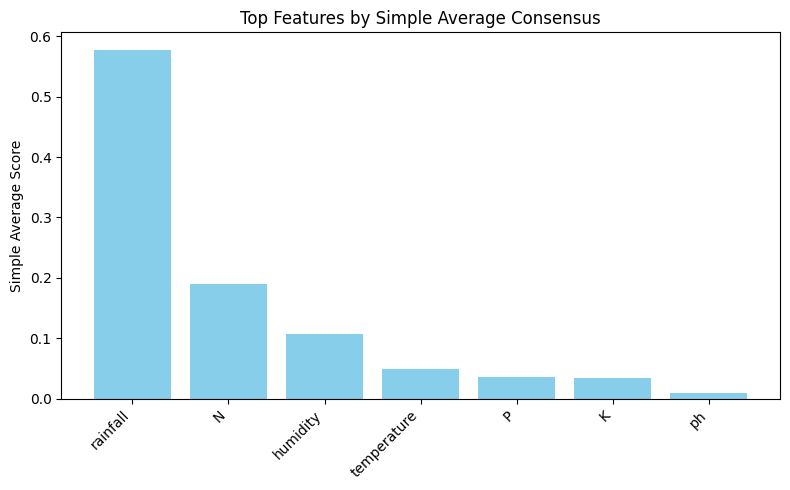

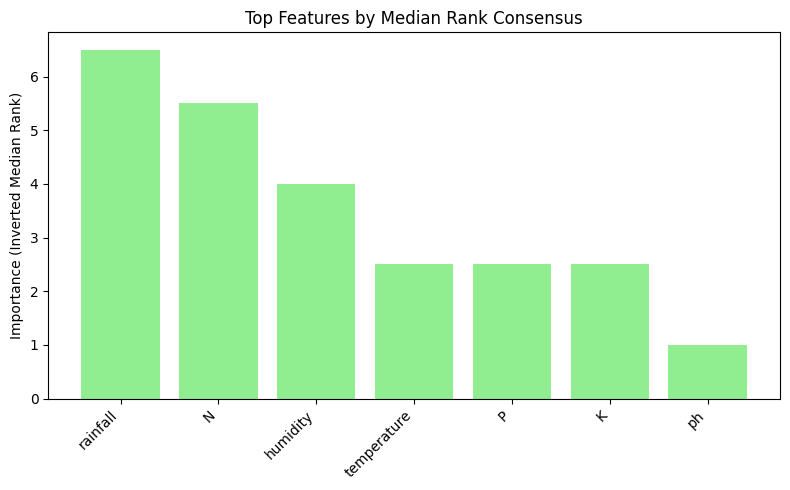

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the consensus table
consensus_path = "/content/drive/MyDrive/rice_feature_importance_consensus_balanced.csv"
df = pd.read_csv(consensus_path)

# ------------------------------
# 1. Bar chart for Simple Average Score
# ------------------------------
top_simple_avg = df.sort_values(by="Simple_Avg_Score", ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.bar(top_simple_avg["Feature"], top_simple_avg["Simple_Avg_Score"], color="skyblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Simple Average Score")
plt.title("Top Features by Simple Average Consensus")
plt.tight_layout()
plt.show()

# ------------------------------
# 2. Bar chart for Median Rank (inverted for visual clarity)
# ------------------------------
# Invert so higher bar = better feature
df["Median_Rank_Inverted"] = df["Median_Rank"].max() - df["Median_Rank"] + 1

top_median_rank = df.sort_values(by="Median_Rank", ascending=True).head(10)

plt.figure(figsize=(8, 5))
plt.bar(top_median_rank["Feature"],
        df.loc[top_median_rank.index, "Median_Rank_Inverted"],
        color="lightgreen")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importance (Inverted Median Rank)")
plt.title("Top Features by Median Rank Consensus")
plt.tight_layout()
plt.show()
